# This project is attempts to analyze honeypots using an entropy based approach

The data comes from a cowrie SSH honeypot that was setup to analyze what people would do in an SSH honeypot and what 

In [25]:
print('hello world')

# coutnt number of profiles in ip_entopies.csv
import pandas as pd
df = pd.read_csv('datasets/ip_entropies.csv')
print(f'Number of profiles in ip_entropies.csv: {len(df)}')

hello world
Number of profiles in ip_entropies.csv: 5078


## first we need to normalize data seen in the data set so we will do analysis on completely normalized data

In [26]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


df = pd.read_csv('datasets/ip_entropies.csv')
df['total_sessions'] = pd.to_numeric(df['total_sessions'], errors='coerce')

df = df.dropna()

# Initial data exploration
print('Head of the dataframe:')
print(df.head())

print('\nDataframe info:')
print(df.info())

print('\nDescriptive statistics:')
print(df.describe())

# Normalizing the data
scaler = MinMaxScaler()
normalized_data = df.dropna()
normalized_data = normalized_data.drop(columns=['src_ip'], axis=1)
normalized_data = scaler.fit_transform(normalized_data)

normalized_data = pd.DataFrame(normalized_data, columns=df.columns[1:])

print("\n\nNORMALIZED STATISTICS")
print('\nHead of the normalized dataframe:')
print(normalized_data.head())

print('\nNormalized dataframe info:')
print(normalized_data.info())

print('\nNormalized descriptive statistics:')
print(normalized_data.describe())


Head of the dataframe:
         src_ip  total_sessions  username_entropy  password_entropy  \
0   1.117.26.65             3.0          0.918296          1.584963   
1   1.13.79.144             1.0          0.000000          0.000000   
2   1.14.155.39             3.0          0.000000          0.000000   
3  1.158.136.26             3.0          0.918296          1.584963   
4  1.180.230.98             1.0          0.000000          0.000000   

   command_entropy  
0         1.000000  
1         0.000000  
2         4.247928  
3         1.000000  
4         0.000000  

Dataframe info:
<class 'pandas.core.frame.DataFrame'>
Index: 5077 entries, 0 to 5077
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   src_ip            5077 non-null   object 
 1   total_sessions    5077 non-null   float64
 2   username_entropy  5077 non-null   float64
 3   password_entropy  5077 non-null   float64
 4   command_entropy   5

## now that we have normalized the data we can look at some explorative stats to see what is happening in the data frame

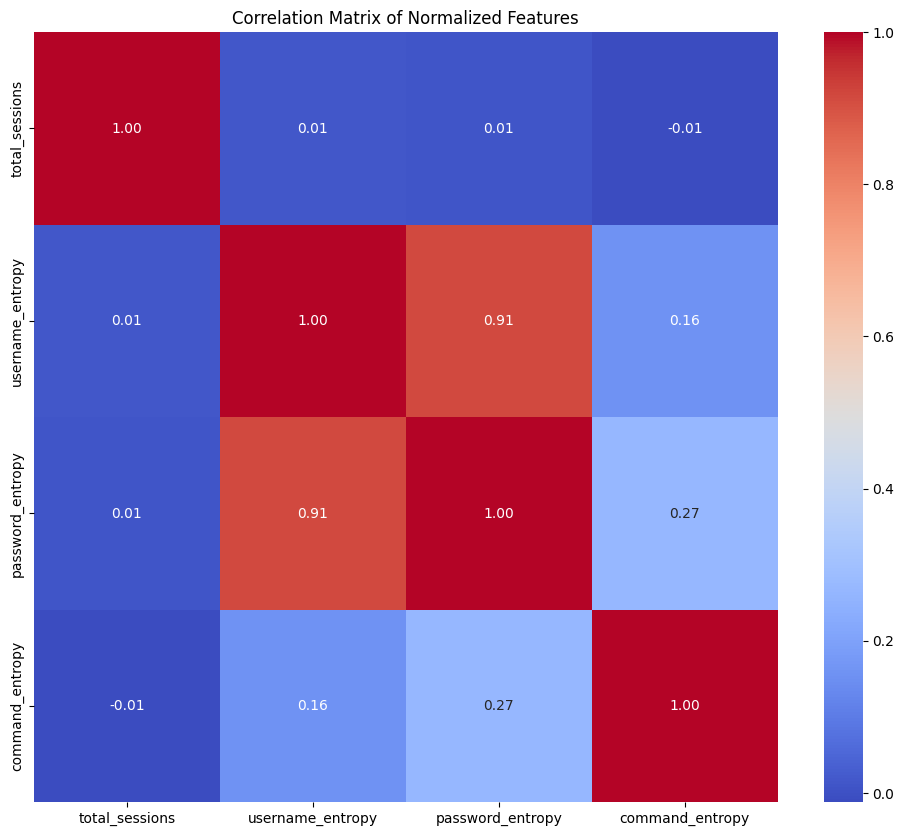

In [27]:
correlation_matrix = normalized_data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Normalized Features')
plt.savefig('icc_plots/correlation_matrix_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()  

# now we can make a dendrogram to better understand the clusters we may have in the data

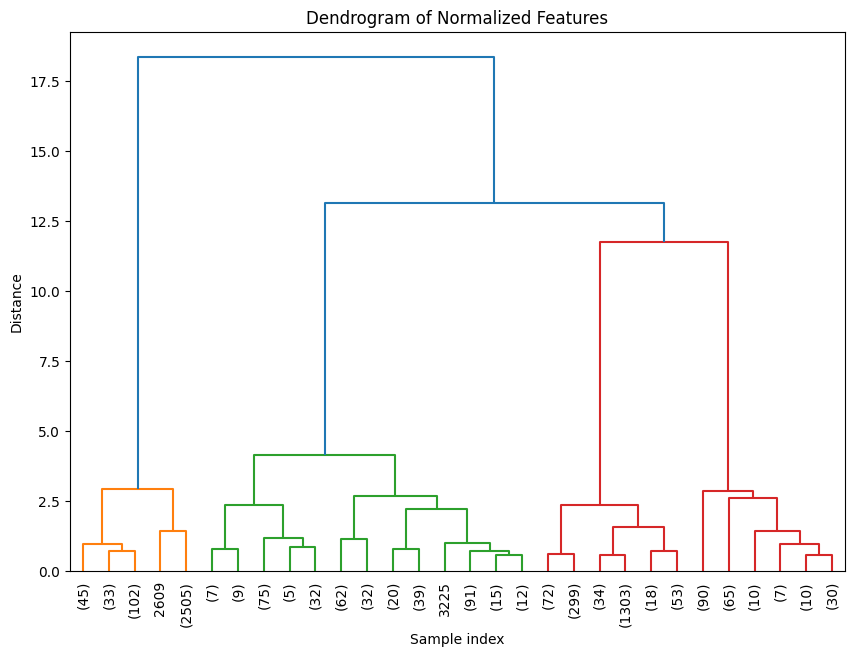

In [28]:
# make an initial dendrogram to better undertand the clusters we may have in the data
linked = linkage(normalized_data, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(
    linked,
    truncate_mode='lastp',   # or 'level'
    p=30,                    # show only last 30 merged clusters
    show_leaf_counts=True,
    leaf_rotation=90,
)
plt.title('Dendrogram of Normalized Features')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.savefig('icc_plots/dendrogram_all_features.png', dpi=300, bbox_inches='tight')
plt.show()  

## now we will see what the dendrograms look like with excluding different features and also pairwise features

### dendrograms with 3 features

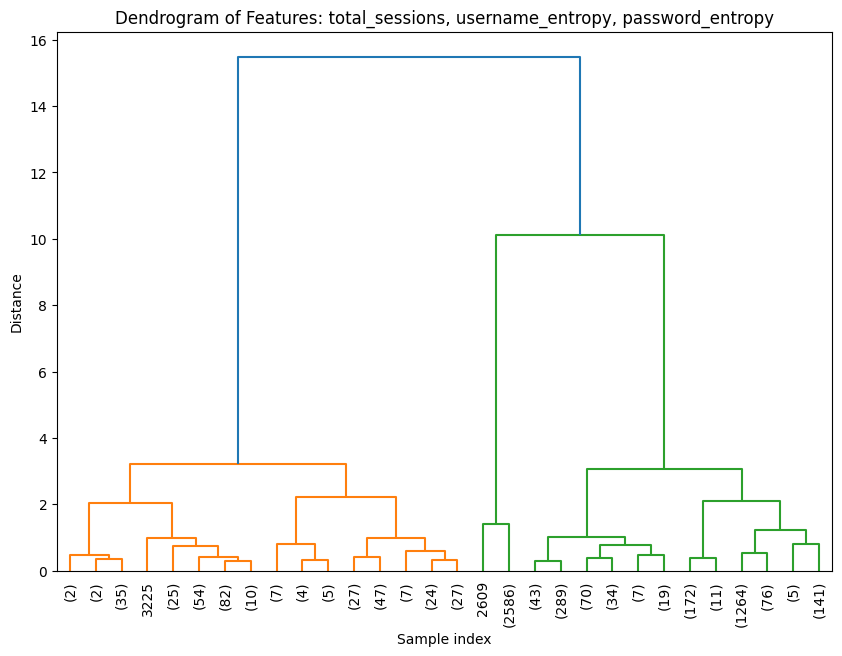

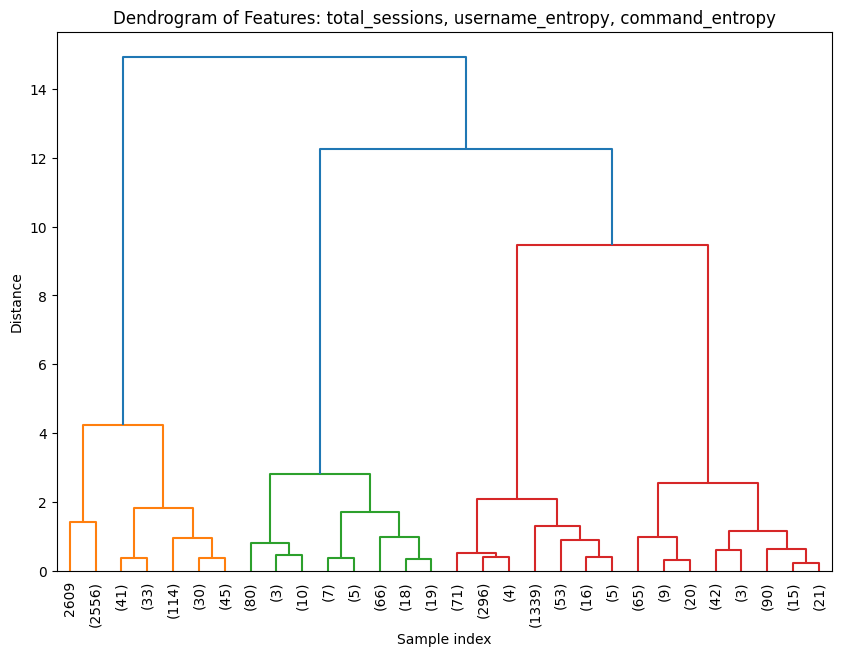

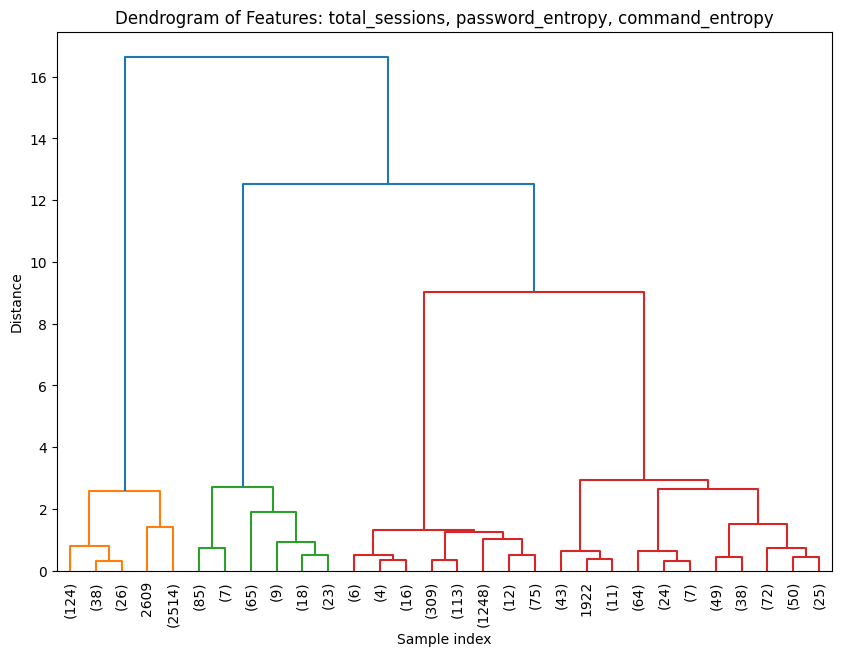

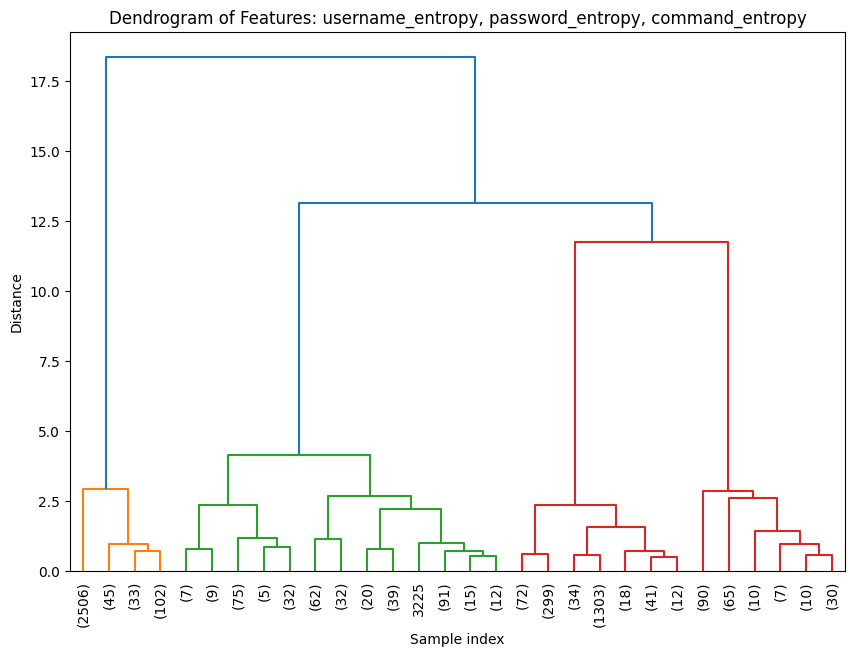

In [29]:
# make dendrograms excluding different features and also pairwise features

# 3 features at a time 
features = normalized_data.columns
for i in range(len(features)):
    for j in range(i+1, len(features)):
        for k in range(j+1, len(features)):
            subset = normalized_data[[features[i], features[j], features[k]]]
            linked = linkage(subset, method='ward')
            plt.figure(figsize=(10, 7))
            dendrogram(
                linked,
                truncate_mode='lastp',
                p=30,
                show_leaf_counts=True,
                leaf_rotation=90,
            )
            plt.title(f'Dendrogram of Features: {features[i]}, {features[j]}, {features[k]}')
            plt.xlabel('Sample index')
            plt.ylabel('Distance')
            plt.show()

### Dendrograms with 2 features

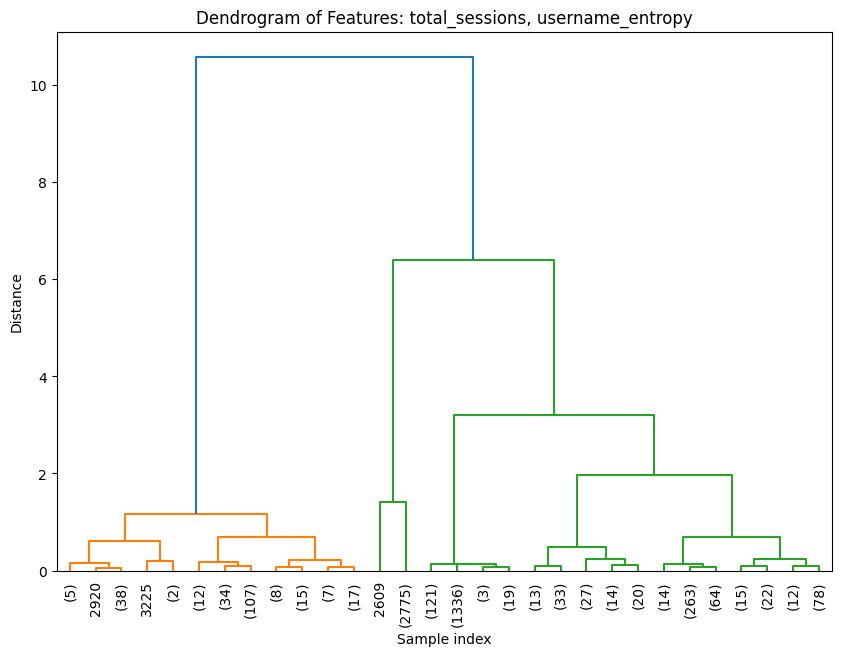

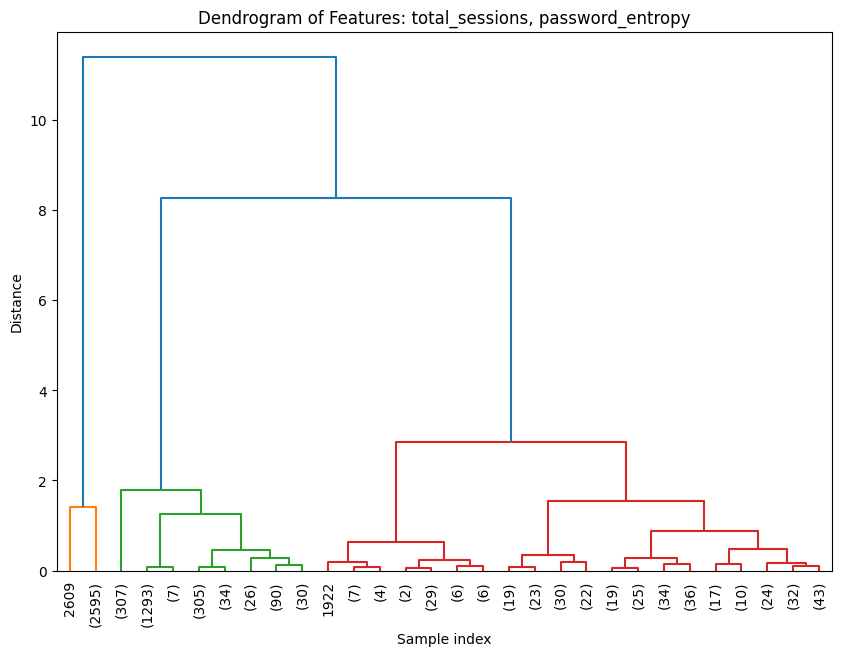

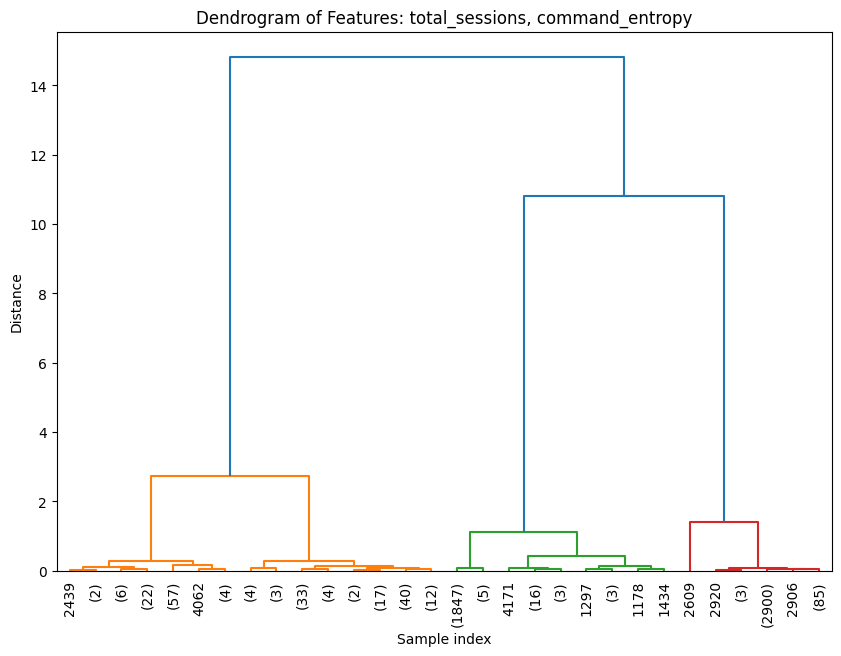

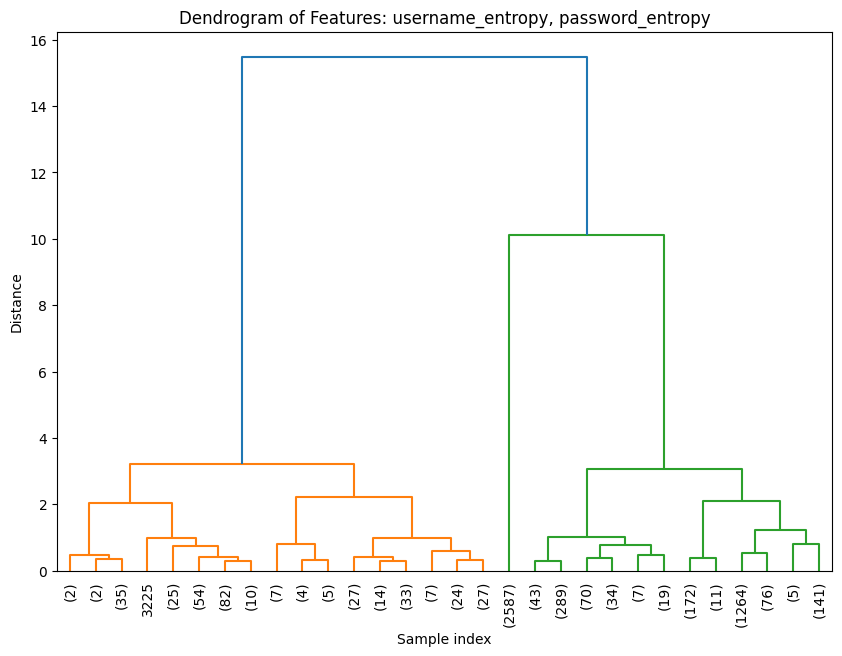

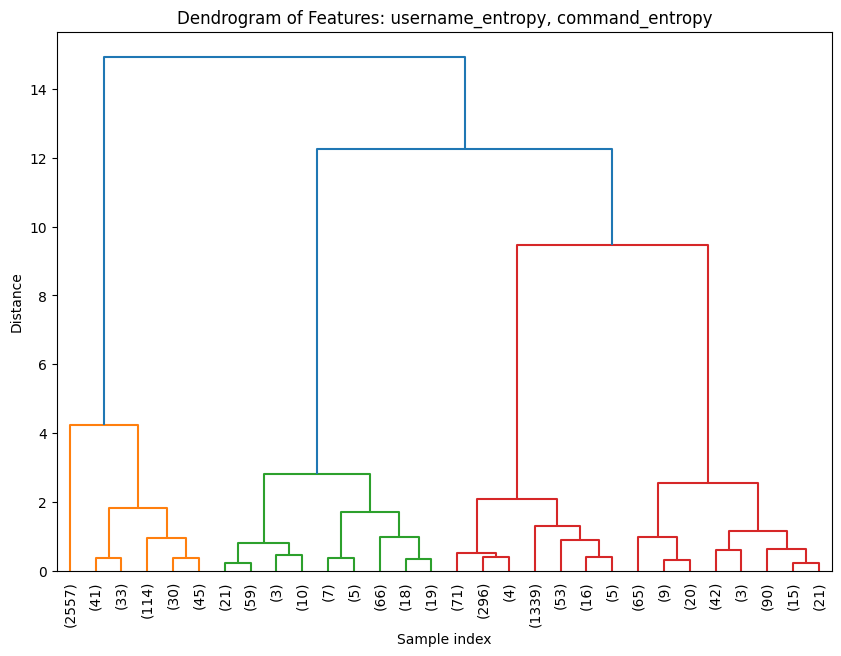

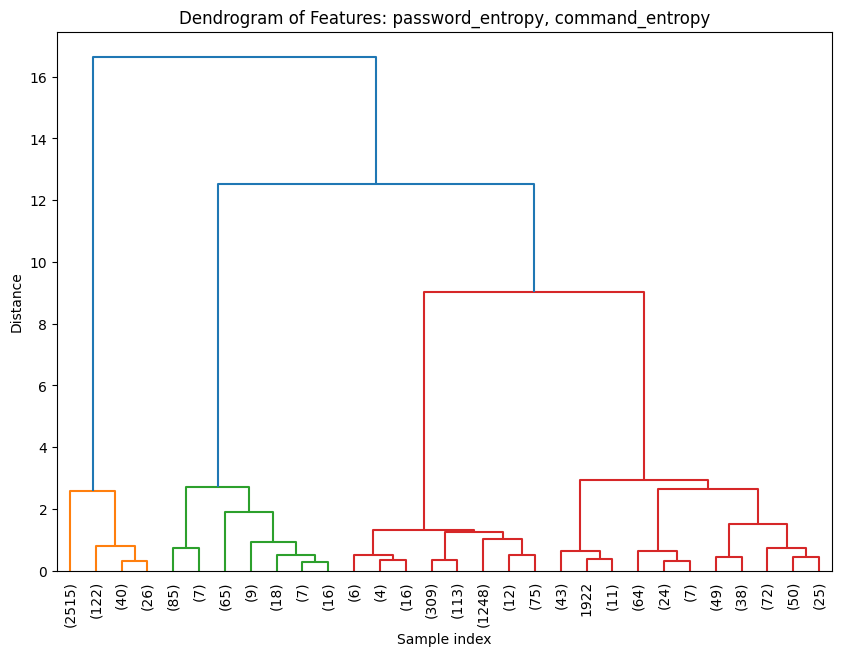

In [30]:
# create dendrograms with 2 features at a time
for i in range(len(features)):
    for j in range(i+1, len(features)):
        subset = normalized_data[[features[i], features[j]]]
        linked = linkage(subset, method='ward')
        plt.figure(figsize=(10, 7))
        dendrogram(
            linked,
            truncate_mode='lastp',
            p=30,
            show_leaf_counts=True,
            leaf_rotation=90,
        )
        plt.title(f'Dendrogram of Features: {features[i]}, {features[j]}')
        plt.xlabel('Sample index')
        plt.ylabel('Distance')
        plt.show()

## Check best number of clusters to have

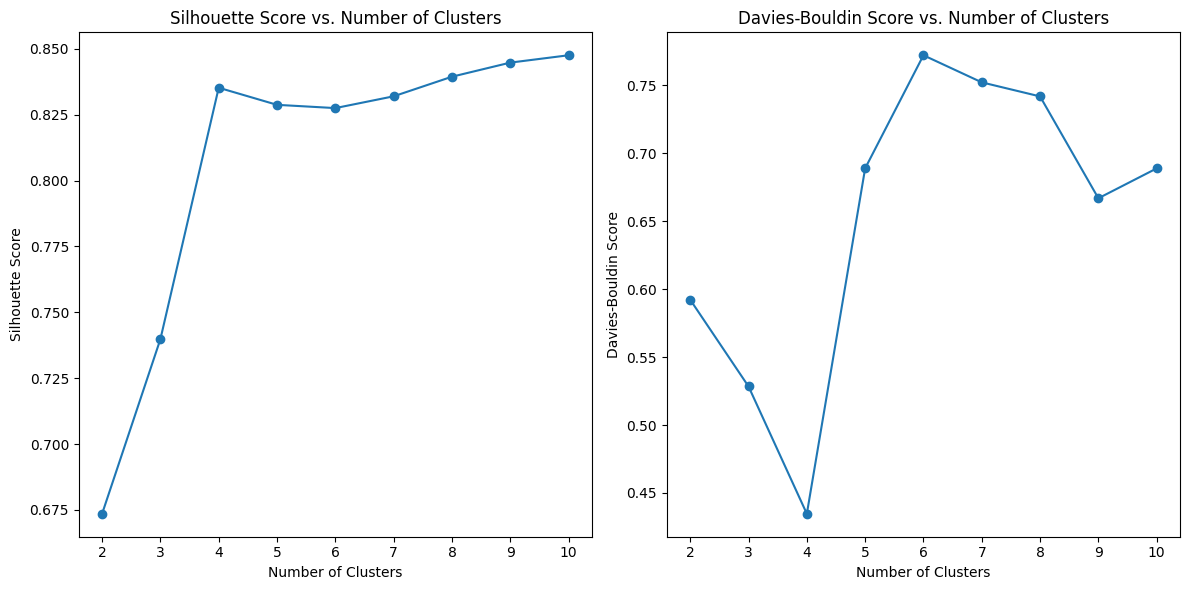

In [31]:
# now we need to evaluation the best number of clusters to have using silhouette score and davies bouldin score
from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette_scores = []
davies_bouldin_scores = []

for n_clusters in range(2, 11):
    cluster_labels = fcluster(linked, n_clusters, criterion='maxclust')
    silhouette_scores.append(silhouette_score(normalized_data, cluster_labels))
    davies_bouldin_scores.append(davies_bouldin_score(normalized_data, cluster_labels))

# Plotting the scores
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), davies_bouldin_scores, marker='o')
plt.title('Davies-Bouldin Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Score')

plt.tight_layout()
plt.savefig('icc_plots/hierarchical_cluster_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

## Determined 4 to be the best number of clusters so now we will assign labels based on that 

In [32]:
# assign labels based on the best number of clusters determined
best_n_clusters = 4  # Assuming 4 is determined to be the best number of clusters
cluster_labels = fcluster(linked, best_n_clusters, criterion='maxclust')
normalized_data['cluster'] = cluster_labels

# count the number of samples in each cluster
cluster_counts = normalized_data['cluster'].value_counts()
print("Cluster Counts:")
print(cluster_counts)

# current head of the data with cluster labels
print("Data with Cluster Labels:")
print(normalized_data.head())


Cluster Counts:
cluster
1    2703
3    1783
4     384
2     207
Name: count, dtype: int64
Data with Cluster Labels:
   total_sessions  username_entropy  password_entropy  command_entropy  \
0        0.000026          0.099939          0.174162         0.223193   
1        0.000000          0.000000          0.000000         0.000000   
2        0.000026          0.000000          0.000000         0.948108   
3        0.000026          0.099939          0.174162         0.223193   
4        0.000000          0.000000          0.000000         0.000000   

   cluster  
0        3  
1        1  
2        2  
3        3  
4        1  


## examine the averages for each of the clusters

In [33]:
# we are going to examine the averages for each of the clusters
cluster_averages = normalized_data.groupby('cluster').mean()
print("Normalized Cluster Averages:")
print(cluster_averages)

# we can also merge the cluster labels back to the original dataframe to see the original values per cluster
df_with_clusters = df.copy()
df_with_clusters['cluster'] = cluster_labels
print("Original Data with Cluster Labels:")
print(df_with_clusters.head())

# examine the averages for each of the clusters in the original data
# drop ip address column for averaging
original_cluster_averages = df_with_clusters.drop(columns=['src_ip']).groupby('cluster').mean()
print("Original Cluster Averages:")
print(original_cluster_averages)

Normalized Cluster Averages:
         total_sessions  username_entropy  password_entropy  command_entropy
cluster                                                                     
1              0.000455          0.008007          0.009653         0.000000
2              0.000091          0.059990          0.115828         0.829407
3              0.000039          0.112616          0.179776         0.225597
4              0.001101          0.441327          0.495776         0.056068
Original Data with Cluster Labels:
         src_ip  total_sessions  username_entropy  password_entropy  \
0   1.117.26.65             3.0          0.918296          1.584963   
1   1.13.79.144             1.0          0.000000          0.000000   
2   1.14.155.39             3.0          0.000000          0.000000   
3  1.158.136.26             3.0          0.918296          1.584963   
4  1.180.230.98             1.0          0.000000          0.000000   

   command_entropy  cluster  
0         1.00000

##  now we decide centroids using kmeans 

In [34]:
import numpy as np
from sklearn.cluster import KMeans

np.random.seed(42)  # For reproducibility

# --- choose EXACT columns used to fit KMeans (everything except your pre-existing 'cluster' labels) ---
kmeans_df = normalized_data.drop(columns=['cluster'])
feature_cols = kmeans_df.columns.tolist()  # lock the feature set & order

# --- fit KMeans on those columns ---
kmeans = KMeans(n_clusters=best_n_clusters, random_state=42, n_init='auto')
kmeans.fit(kmeans_df.values)
kmeans_labels = kmeans.labels_                 # 0-based
normalized_data['kmeans_cluster'] = kmeans_labels + 1  # +1 to mirror fcluster



print("Data with KMeans Cluster Labels:")
print(normalized_data.head())

# --- comparisons ---
comparison = normalized_data[['cluster', 'kmeans_cluster']]
print("Cluster Assignment Comparison:")
print(comparison.head())

hierarchical_counts = normalized_data['cluster'].value_counts().sort_index()
kmeans_counts = normalized_data['kmeans_cluster'].value_counts().sort_index()
comparison_counts = pd.DataFrame({'Hierarchical': hierarchical_counts, 'KMeans': kmeans_counts})
print("Cluster Counts Comparison:")
print(comparison_counts)

# --- KMeans centroids as a DF (same feature order) ---
kmeans_centroids = kmeans.cluster_centers_  # shape: (k, len(feature_cols))
kmeans_centroids_df = pd.DataFrame(kmeans_centroids, columns=feature_cols)
kmeans_centroids_df['kmeans_cluster'] = np.arange(1, best_n_clusters + 1)
print("KMeans Centroids:")
print(kmeans_centroids_df)

# --- attach IPs (assumes df and normalized_data have identical row order/index) ---
normalized_data_with_ips = normalized_data.copy()
normalized_data_with_ips['src_ip'] = df['src_ip'].values

# --- find closest IP to each centroid (distance computed in same feature space used to fit KMeans) ---
kmeans_centroids_with_ips = []
closest_indices = []  # DataFrame indices of closest IPs

for i in range(best_n_clusters):
    label_val = i + 1  # because you stored kmeans_cluster as 1..k
    cluster_data = normalized_data_with_ips[normalized_data_with_ips['kmeans_cluster'] == label_val]

    if cluster_data.empty:
        # rare but possible if a cluster ends up empty
        continue

    # use the exact same columns used for KMeans fit, in the same order
    cluster_X = cluster_data[feature_cols].values
    centroid = kmeans.cluster_centers_[i]  # shape: (len(feature_cols),)

    # distances in the SAME space (here: already-normalized data)
    dists = np.linalg.norm(cluster_X - centroid, axis=1)
    j = int(np.argmin(dists))

    # recover the original DataFrame index for the closest row
    closest_idx = cluster_data.index.to_numpy()[j]
    closest_indices.append(closest_idx)

    closest_ip = normalized_data_with_ips.at[closest_idx, 'src_ip']
    centroid_dict = dict(zip(feature_cols, centroid))
    centroid_dict['kmeans_cluster'] = label_val
    centroid_dict['closest_ip'] = closest_ip
    centroid_dict['closest_index'] = closest_idx
    centroid_dict['distance_to_centroid'] = float(dists[j])
    kmeans_centroids_with_ips.append(centroid_dict)

print("Indices of closest IPs per centroid:", closest_indices)
print(pd.DataFrame(kmeans_centroids_with_ips).sort_values('kmeans_cluster'))


Data with KMeans Cluster Labels:
   total_sessions  username_entropy  password_entropy  command_entropy  \
0        0.000026          0.099939          0.174162         0.223193   
1        0.000000          0.000000          0.000000         0.000000   
2        0.000026          0.000000          0.000000         0.948108   
3        0.000026          0.099939          0.174162         0.223193   
4        0.000000          0.000000          0.000000         0.000000   

   cluster  kmeans_cluster  
0        3               1  
1        1               2  
2        2               1  
3        3               1  
4        1               2  
Cluster Assignment Comparison:
   cluster  kmeans_cluster
0        3               1
1        1               2
2        2               1
3        3               1
4        1               2
Cluster Counts Comparison:
   Hierarchical  KMeans
1          2703    1990
2           207    2665
3          1783     261
4           384     161
KMeans C

## use silhouette and DBI to evaluate clusters for kmeans

KMeans Silhouette Score: 0.7625491147852402
KMeans Davies-Bouldin Index: 0.7336434879976479


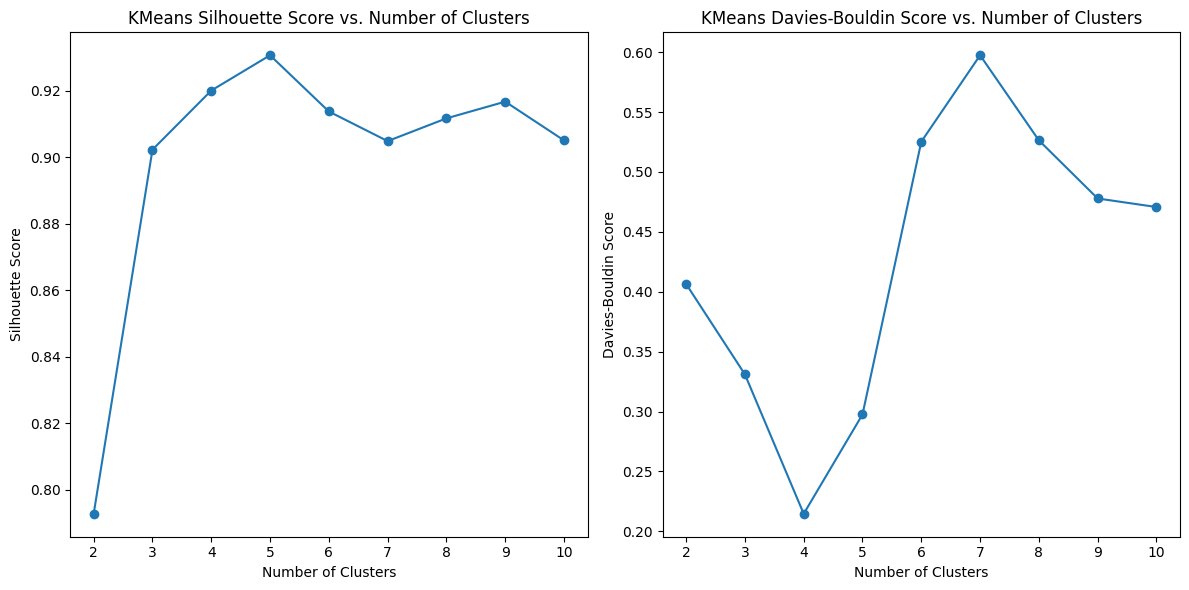

In [35]:
# use silhouette and DBI to evaluate clusters for kmeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette_avg = silhouette_score(kmeans_df.values, kmeans.labels_)
dbi = davies_bouldin_score(kmeans_df.values, kmeans.labels_)
print(f"KMeans Silhouette Score: {silhouette_avg}")
print(f"KMeans Davies-Bouldin Index: {dbi}")    
#!/usr/bin/env python3

# make graphs to check number of clusters for kmeans using the normalized dataframe from before
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import numpy as np  

silhouette_scores = []
davies_bouldin_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(normalized_data.drop(columns=['cluster']))
    silhouette_avg = silhouette_score(normalized_data.drop(columns=['cluster']), labels)
    dbi = davies_bouldin_score(normalized_data.drop(columns=['cluster']), labels)
    silhouette_scores.append(silhouette_avg)
    davies_bouldin_scores.append(dbi)
# Plotting the scores
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('KMeans Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.subplot(1, 2, 2)
plt.plot(k_range, davies_bouldin_scores, marker='o')
plt.title('KMeans Davies-Bouldin Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Score')
plt.tight_layout()
plt.savefig('icc_plots/kmeans_cluster_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()





## explore the kmeans clusters datas

In [36]:
# take original dataframe with kmeans labels and explore the clusters
df_with_kmeans = df.copy()
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(normalized_data.drop(columns=['cluster']))
df_with_kmeans['kmeans_cluster'] = kmeans_labels + 1  # +1 to mirror fcluster
print("Original Data with KMeans Cluster Labels:")
print(df_with_kmeans.head())

df_with_kmeans.to_csv('datasets/ip_entropies_with_kmeans.csv', index=False)


# now explore each of the kmeans clusters
for cluster_num in range(1, 5):
    cluster_data = df_with_kmeans[df_with_kmeans['kmeans_cluster'] == cluster_num]
    print(f"\nKMeans Cluster {cluster_num} Statistics:")
    print(cluster_data.describe())

Original Data with KMeans Cluster Labels:
         src_ip  total_sessions  username_entropy  password_entropy  \
0   1.117.26.65             3.0          0.918296          1.584963   
1   1.13.79.144             1.0          0.000000          0.000000   
2   1.14.155.39             3.0          0.000000          0.000000   
3  1.158.136.26             3.0          0.918296          1.584963   
4  1.180.230.98             1.0          0.000000          0.000000   

   command_entropy  kmeans_cluster  
0         1.000000               1  
1         0.000000               2  
2         4.247928               1  
3         1.000000               1  
4         0.000000               2  

KMeans Cluster 1 Statistics:
       total_sessions  username_entropy  password_entropy  command_entropy  \
count     1990.000000       1990.000000       1990.000000      1990.000000   
mean         4.511055          0.982234          1.574670         1.290521   
std          6.108836          0.504011      

## look at the centroids for each of the clusters

In [37]:
# look at the details of centroids for each of the clusters

# recorded indexes of closest IPs per centroid: [47, 1142, 373, 2246]

# look at the centroids for each of the clusters
for idx in [47, 1142, 373, 2246]:
    print(df_with_kmeans.iloc[idx]) 


src_ip              101.126.155.124
total_sessions                  5.0
username_entropy           0.918296
password_entropy           1.584963
command_entropy                 1.0
kmeans_cluster                    1
Name: 47, dtype: object
src_ip              124.163.255.210
total_sessions                 30.0
username_entropy                0.0
password_entropy                0.0
command_entropy                 0.0
kmeans_cluster                    2
Name: 1143, dtype: object
src_ip              103.70.115.38
total_sessions               35.0
username_entropy         2.329391
password_entropy         3.240581
command_entropy               0.0
kmeans_cluster                  3
Name: 373, dtype: object
src_ip              176.37.33.53
total_sessions              30.0
username_entropy        4.906891
password_entropy        4.840224
command_entropy              0.0
kmeans_cluster                 4
Name: 2247, dtype: object


# take an individual look at each cluster and their own clusters

In [38]:
# take a look at the averages for each of the kmeans clusters
# split the dataframe by kmeans cluster
kmeans_cluster_1 = df_with_kmeans[df_with_kmeans['kmeans_cluster'] == 1]
kmeans_cluster_2 = df_with_kmeans[df_with_kmeans['kmeans_cluster'] == 2]
kmeans_cluster_3 = df_with_kmeans[df_with_kmeans['kmeans_cluster'] == 3]
kmeans_cluster_4 = df_with_kmeans[df_with_kmeans['kmeans_cluster'] == 4]

# removing IP and Cluster ID
kmeans_cluster_1_clean = kmeans_cluster_1.drop(columns=['src_ip', 'kmeans_cluster'])
kmeans_cluster_2_clean = kmeans_cluster_2.drop(columns=['src_ip', 'kmeans_cluster'])
kmeans_cluster_3_clean = kmeans_cluster_3.drop(columns=['src_ip', 'kmeans_cluster'])
kmeans_cluster_4_clean = kmeans_cluster_4.drop(columns=['src_ip', 'kmeans_cluster'])

print("\nKMeans Cluster 1 Averages:")
print(kmeans_cluster_1_clean.mean())
print("\nKMeans Cluster 2 Averages:")
print(kmeans_cluster_2_clean.mean())
print("\nKMeans Cluster 3 Averages:")
print(kmeans_cluster_3_clean.mean())
print("\nKMeans Cluster 4 Averages:")
print(kmeans_cluster_4_clean.mean())


print("Cluster counts for KMeans:")
print(f"KMeans Cluster 1: {len(kmeans_cluster_1)}")
print(f"KMeans Cluster 2: {len(kmeans_cluster_2)}")
print(f"KMeans Cluster 3: {len(kmeans_cluster_3)}")
print(f"KMeans Cluster 4: {len(kmeans_cluster_4)}")


KMeans Cluster 1 Averages:
total_sessions      4.511055
username_entropy    0.982234
password_entropy    1.574670
command_entropy     1.290521
dtype: float64

KMeans Cluster 2 Averages:
total_sessions      36.195872
username_entropy     0.047305
password_entropy     0.063193
command_entropy      0.000000
dtype: float64

KMeans Cluster 3 Averages:
total_sessions      29.043478
username_entropy     2.291552
password_entropy     3.171781
command_entropy      0.077417
dtype: float64

KMeans Cluster 4 Averages:
total_sessions      119.785441
username_entropy      4.848691
password_entropy      4.952483
command_entropy       0.334485
dtype: float64
Cluster counts for KMeans:
KMeans Cluster 1: 1990
KMeans Cluster 2: 2665
KMeans Cluster 3: 161
KMeans Cluster 4: 261


### KMEANS Cluster analysis

In [39]:
def describe_cluster(cluster_df):
    stats = cluster_df[features].agg(['mean', 'median', 'std', 'min', 'max'])
    return stats

# cluster 1
print("\nKMeans Cluster 1 Detailed Statistics:")
print(describe_cluster(kmeans_cluster_1_clean))
# cluster 2
print("\nKMeans Cluster 2 Detailed Statistics:")
print(describe_cluster(kmeans_cluster_2_clean))
# cluster 3
print("\nKMeans Cluster 3 Detailed Statistics:")
print(describe_cluster(kmeans_cluster_3_clean))
# cluster 4
print("\nKMeans Cluster 4 Detailed Statistics:")
print(describe_cluster(kmeans_cluster_4_clean))


KMeans Cluster 1 Detailed Statistics:
        total_sessions  username_entropy  password_entropy  command_entropy
mean          4.511055          0.982234          1.574670         1.290521
median        3.000000          0.918296          1.584963         1.000000
std           6.108836          0.504011          0.459159         0.851560
min           1.000000          0.000000          0.000000         0.845351
max         135.000000          4.807355          4.608096         4.480424

KMeans Cluster 2 Detailed Statistics:
        total_sessions  username_entropy  password_entropy  command_entropy
mean         36.195872          0.047305          0.063193              0.0
median        1.000000          0.000000          0.000000              0.0
std        1517.396076          0.236812          0.263344              0.0
min           1.000000          0.000000          0.000000              0.0
max       78295.000000          3.348703          2.175203              0.0

KMeans Cl

#### Cluster 1 analysis

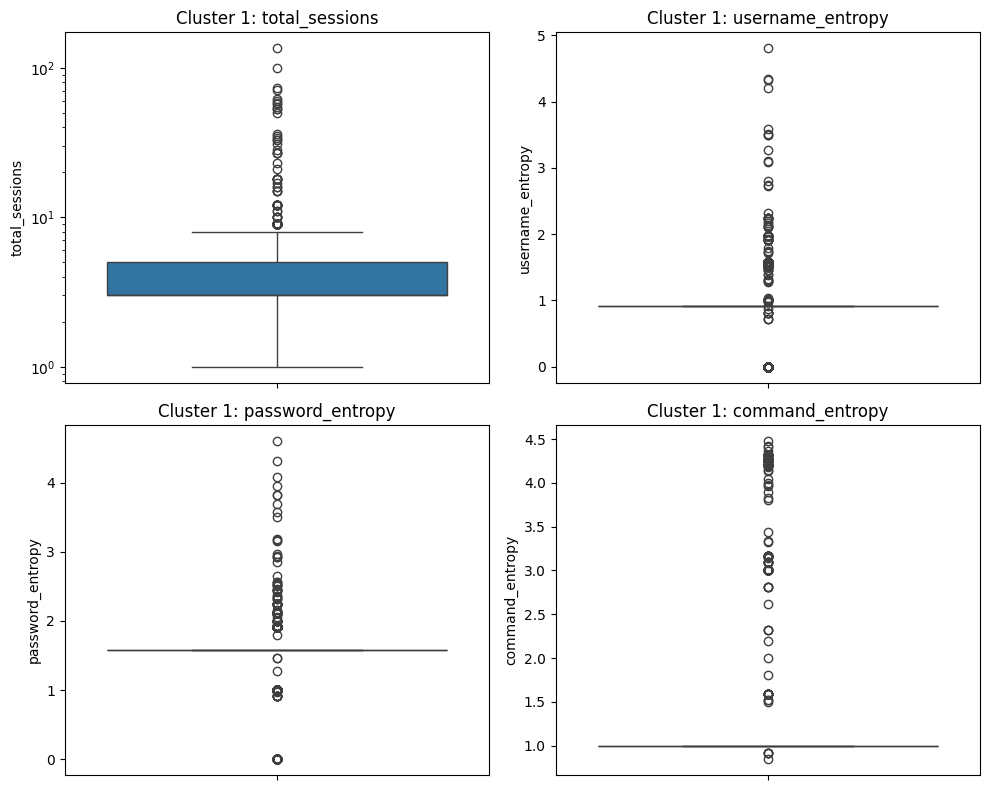

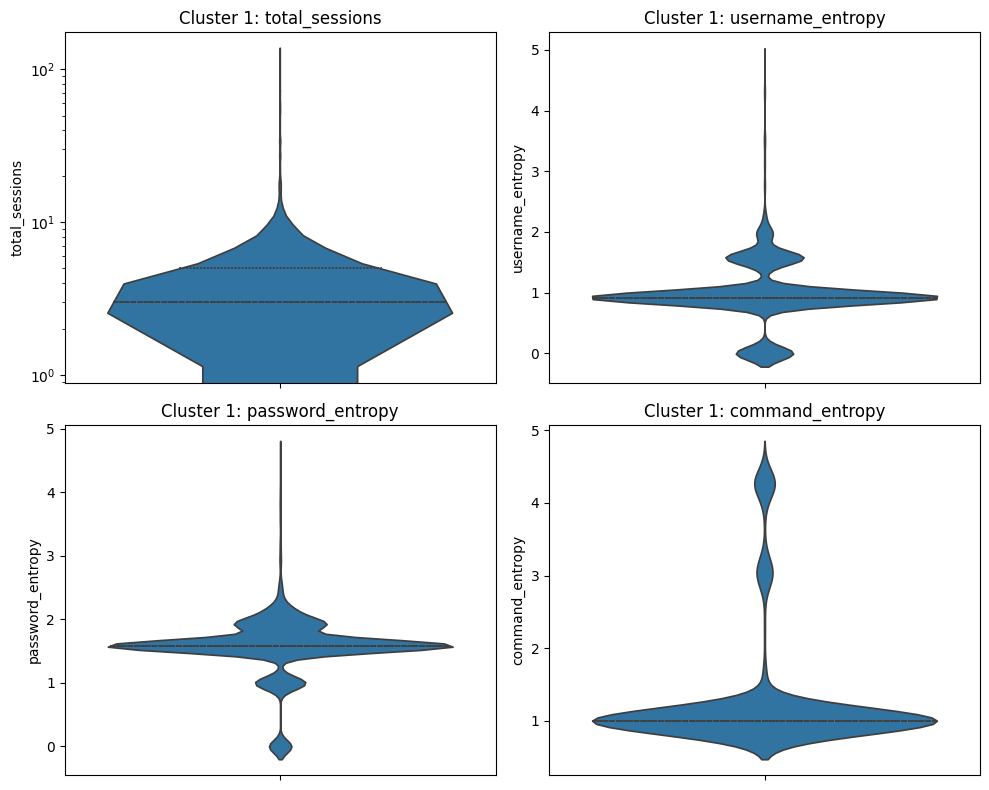

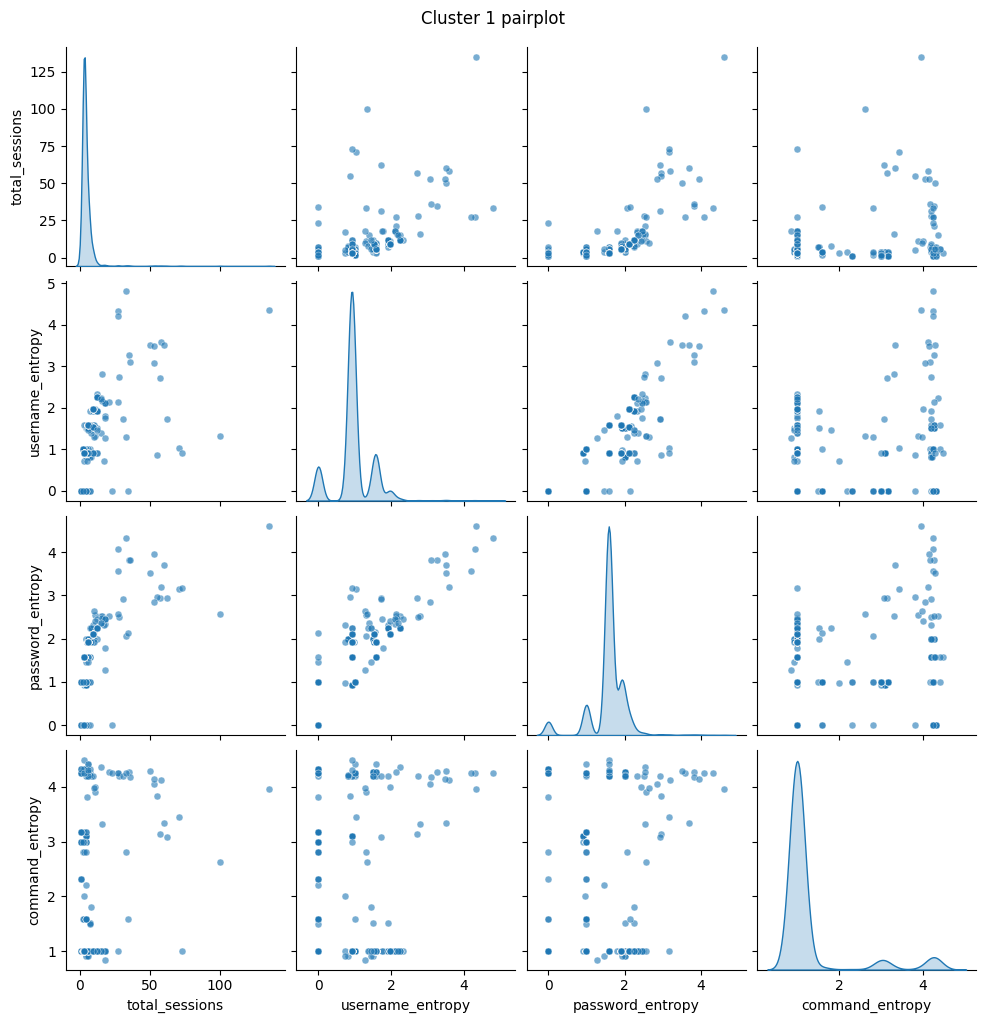

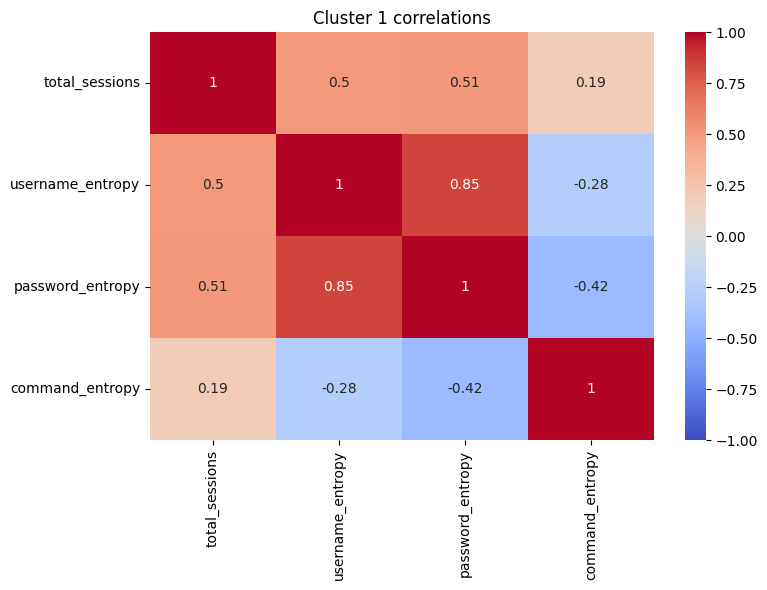

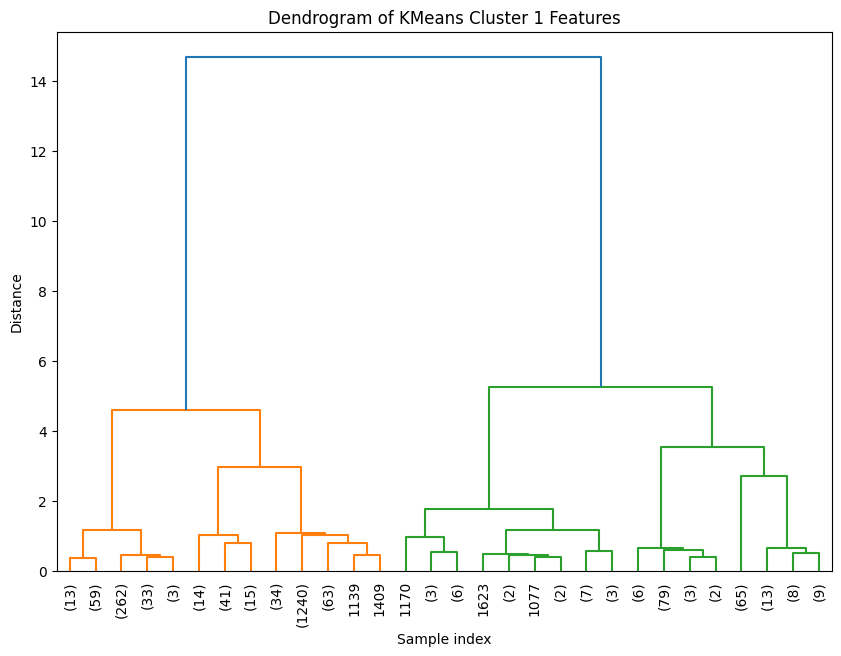

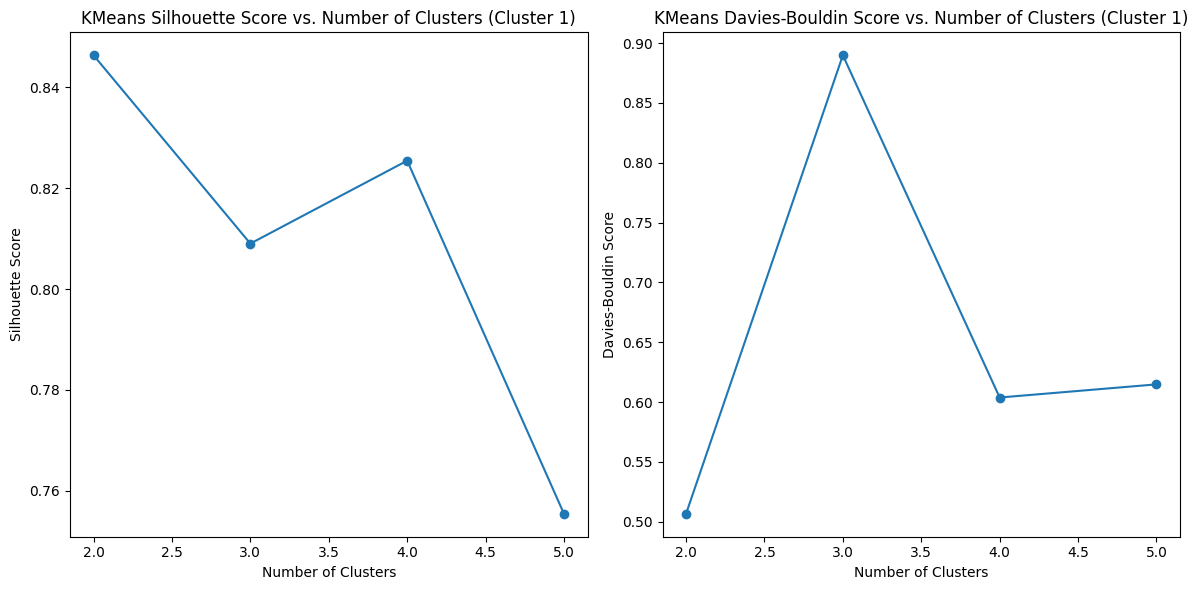

KMeans Cluster 1 Subcluster Labels:
           src_ip  total_sessions  username_entropy  password_entropy  \
0     1.117.26.65             3.0          0.918296          1.584963   
2     1.14.155.39             3.0          0.000000          0.000000   
3    1.158.136.26             3.0          0.918296          1.584963   
13    1.221.66.66             4.0          1.500000          2.000000   
18  1.254.101.182             3.0          0.918296          1.584963   

    command_entropy  kmeans_cluster  subcluster  
0          1.000000               1           1  
2          4.247928               1           2  
3          1.000000               1           1  
13         0.918296               1           1  
18         1.000000               1           1  
KMeans Cluster 1 Subcluster Counts:
subcluster
1    1780
2     210
Name: count, dtype: int64
KMeans Cluster 1 Centroids:
   total_sessions  username_entropy  password_entropy  command_entropy
0        0.023394          0.2157

/tmp/ipykernel_205858/490979323.py:110: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kmeans_cluster_1['subcluster'] = kmeans_cluster_1_labels + 1


In [40]:
def boxplots_cluster(cluster_df, title_prefix="Cluster"):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    for ax, feat in zip(axes, features):
        sns.boxplot(y=cluster_df[feat], ax=ax)
        ax.set_title(f'{title_prefix}: {feat}')
        if feat == 'total_sessions':
            ax.set_yscale('log')  # only sessions on log scale

    plt.tight_layout()
    plt.show()

# cluster 1:
boxplots_cluster(kmeans_cluster_1_clean, title_prefix="Cluster 1")


def violins_cluster(cluster_df, title_prefix="Cluster"):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    for ax, feat in zip(axes, features):
        sns.violinplot(y=cluster_df[feat], ax=ax, inner='quartile')
        ax.set_title(f'{title_prefix}: {feat}')
        if feat == 'total_sessions':
            ax.set_yscale('log')

    plt.tight_layout()
    plt.show()

# cluster 1:
violins_cluster(kmeans_cluster_1_clean, title_prefix="Cluster 1")



def pairplot_cluster(cluster_df, title="Cluster pairplot"):
    temp = cluster_df[features].copy()
    g = sns.pairplot(temp, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 25})
    plt.suptitle(title, y=1.02)
    plt.show()

# cluster 1:
pairplot_cluster(kmeans_cluster_1_clean, title="Cluster 1 pairplot")

def corr_heatmap_cluster(cluster_df, title="Cluster correlations"):
    corr = cluster_df[features].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap='coolwarm')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return corr

# Example:
corr_cluster1 = corr_heatmap_cluster(kmeans_cluster_1_clean, title="Cluster 1 correlations")


# make a dendrogram for cluster 1
# normalize cluster 1 data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
kmeans_cluster_1_normalized = scaler.fit_transform(kmeans_cluster_1_clean)
linked = linkage(kmeans_cluster_1_normalized, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(
    linked,
    truncate_mode='lastp',   # or 'level'
    p=30,                    # show only last 30 merged clusters
    show_leaf_counts=True,
    leaf_rotation=90,
)  
plt.title('Dendrogram of KMeans Cluster 1 Features')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.savefig('nov_14/cluster1/dendrogram_kmeans_cluster_1.png', dpi=300, bbox_inches='tight')
plt.show()  

# find optimal number of clusters for cluster 1 using silhouette and DBI
silhouette_scores = []
davies_bouldin_scores = []  
k_range = range(2, 6)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(kmeans_cluster_1_normalized)
    silhouette_avg = silhouette_score(kmeans_cluster_1_normalized, labels)
    dbi = davies_bouldin_score(kmeans_cluster_1_normalized, labels)
    silhouette_scores.append(silhouette_avg)
    davies_bouldin_scores.append(dbi)
# Plotting the scores
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('KMeans Silhouette Score vs. Number of Clusters (Cluster 1)')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.subplot(1, 2, 2)
plt.plot(k_range, davies_bouldin_scores, marker='o')
plt.title('KMeans Davies-Bouldin Score vs. Number of Clusters (Cluster 1)')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Score')
plt.tight_layout()
plt.savefig('nov_14/cluster1/kmeans_cluster_1_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()


# find centroids for cluster 1
kmeans_cluster_1_kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans_cluster_1_kmeans.fit(kmeans_cluster_1_normalized)
kmeans_cluster_1_labels = kmeans_cluster_1_kmeans.labels_
kmeans_cluster_1['subcluster'] = kmeans_cluster_1_labels + 1
print("KMeans Cluster 1 Subcluster Labels:")
print(kmeans_cluster_1.head())
print("KMeans Cluster 1 Subcluster Counts:")
print(kmeans_cluster_1['subcluster'].value_counts())
# centroids
centroids_cluster_1 = kmeans_cluster_1_kmeans.cluster_centers_
centroids_cluster_1_df = pd.DataFrame(centroids_cluster_1, columns=features)
print("KMeans Cluster 1 Centroids:")
print(centroids_cluster_1_df)



#### Cluster 2 analysis

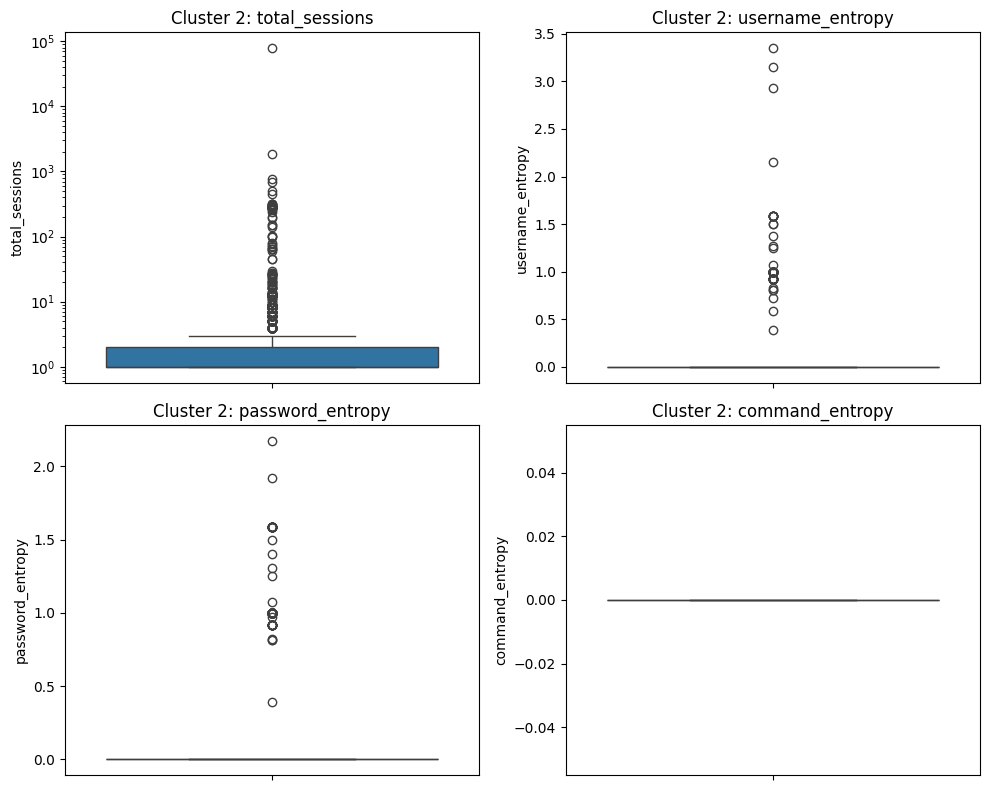

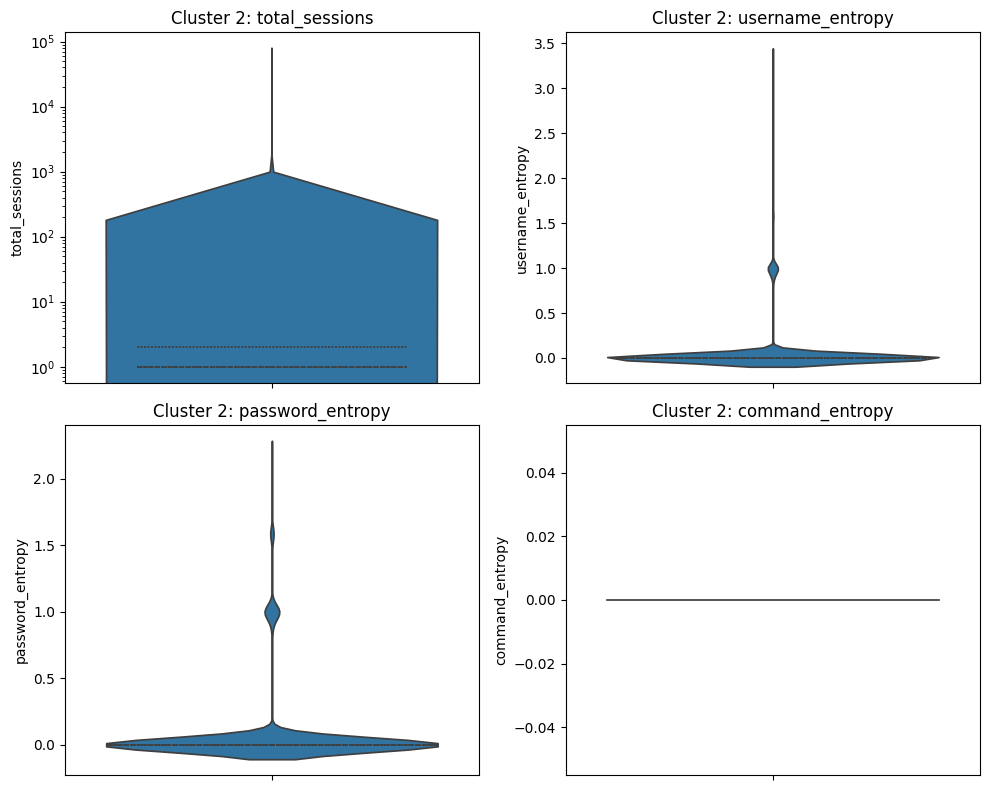

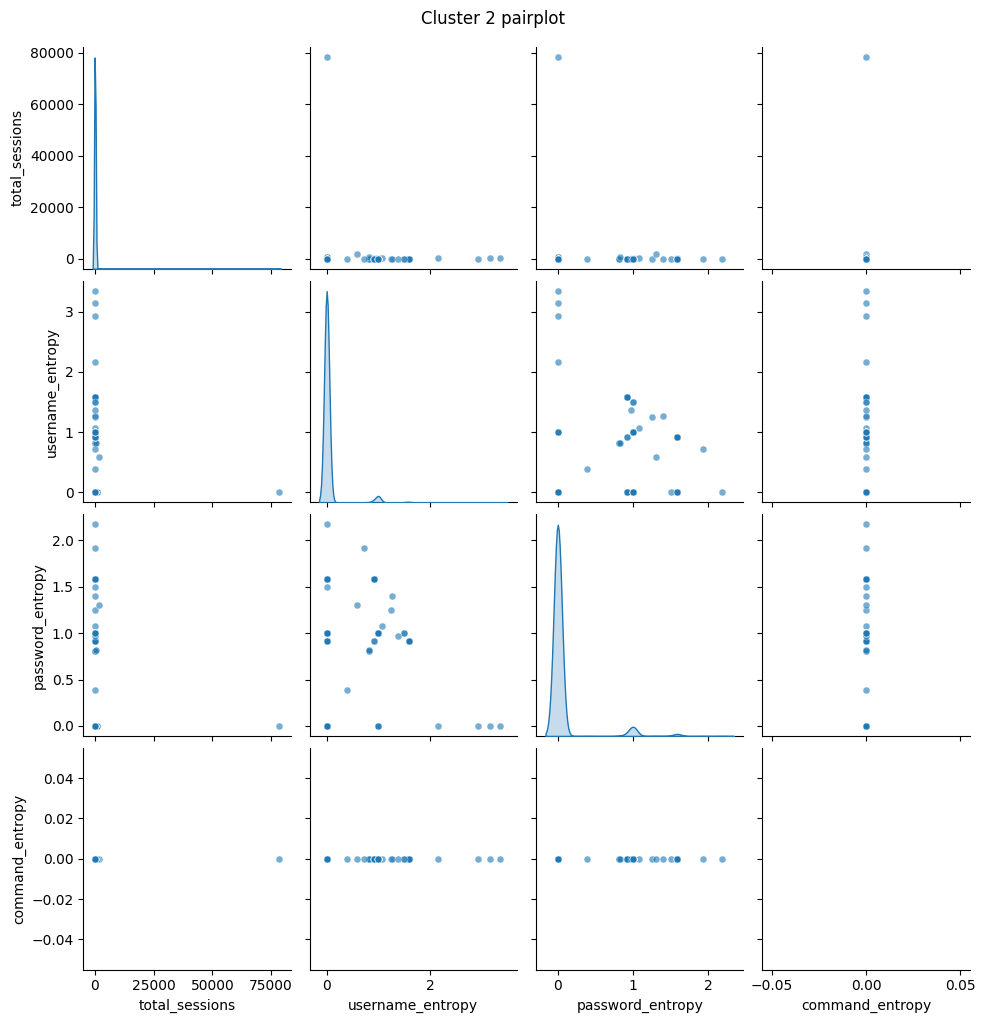

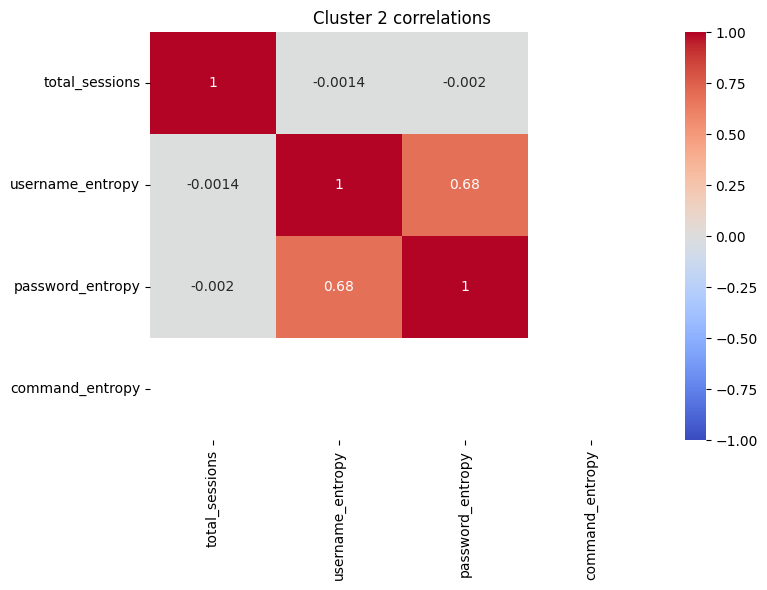

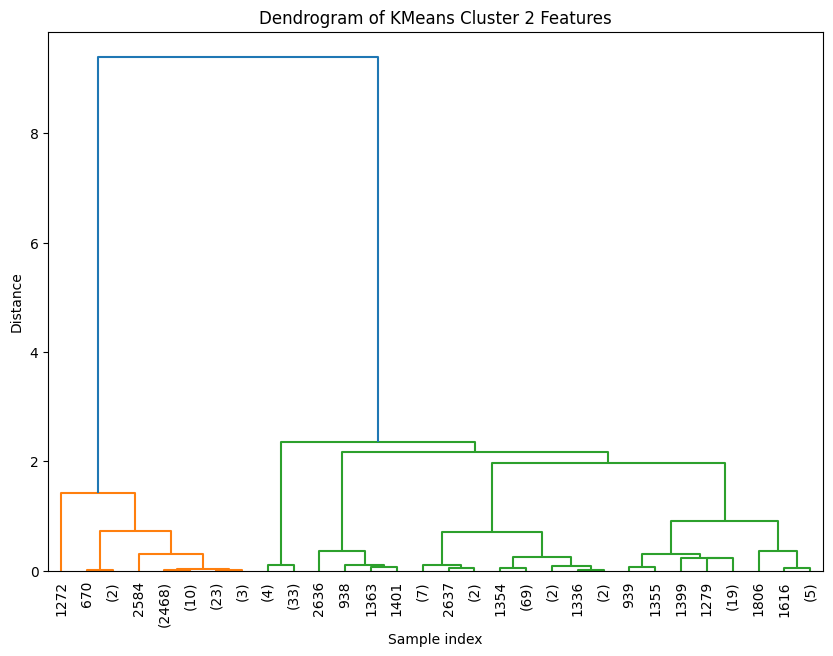

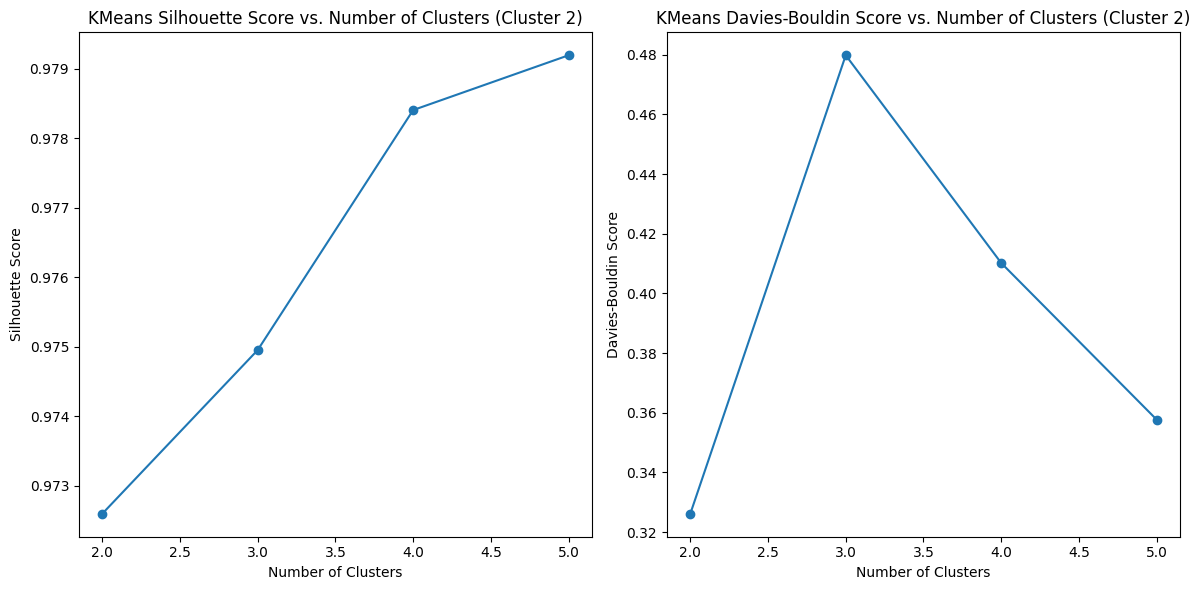

KMeans Cluster 2 Subcluster Labels:
          src_ip  total_sessions  username_entropy  password_entropy  \
1    1.13.79.144             1.0               0.0               0.0   
4   1.180.230.98             1.0               0.0               0.0   
5     1.192.18.4             2.0               0.0               0.0   
6  1.194.210.131             1.0               0.0               0.0   
7  1.194.236.204             7.0               0.0               0.0   

   command_entropy  kmeans_cluster  subcluster  
1              0.0               2           1  
4              0.0               2           1  
5              0.0               2           1  
6              0.0               2           1  
7              0.0               2           1  
KMeans Cluster 2 Subcluster Counts:
subcluster
1    2510
2     155
Name: count, dtype: int64
KMeans Cluster 2 Centroids:
   total_sessions  username_entropy  password_entropy  command_entropy
0        0.000461          0.000659          

/tmp/ipykernel_205858/1540928952.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kmeans_cluster_2['subcluster'] = kmeans_cluster_2_labels + 1


In [41]:
# cluster 2 analysis
boxplots_cluster(kmeans_cluster_2_clean, title_prefix="Cluster 2")
violins_cluster(kmeans_cluster_2_clean, title_prefix="Cluster 2")
pairplot_cluster(kmeans_cluster_2_clean, title="Cluster 2 pairplot")
corr_cluster2 = corr_heatmap_cluster(kmeans_cluster_2_clean, title="Cluster 2 correlations")

# make a dendrogram for cluster 2
# normalize cluster 2 data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
kmeans_cluster_2_normalized = scaler.fit_transform(kmeans_cluster_2_clean)
linked = linkage(kmeans_cluster_2_normalized, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(
    linked,
    truncate_mode='lastp',   # or 'level'
    p=30,                    # show only last 30 merged clusters
    show_leaf_counts=True,
    leaf_rotation=90,
)  
plt.title('Dendrogram of KMeans Cluster 2 Features')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.savefig('nov_14/cluster2/dendrogram_kmeans_cluster_2.png', dpi=300, bbox_inches='tight')
plt.show() 

# find optimal number of subclusters for cluster 2 using silhouette and DBI
silhouette_scores = []
davies_bouldin_scores = []  
k_range = range(2, 6)
for k in k_range:   
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(kmeans_cluster_2_normalized)
    silhouette_avg = silhouette_score(kmeans_cluster_2_normalized, labels)
    dbi = davies_bouldin_score(kmeans_cluster_2_normalized, labels)
    silhouette_scores.append(silhouette_avg)
    davies_bouldin_scores.append(dbi)
# Plotting the scores
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('KMeans Silhouette Score vs. Number of Clusters (Cluster 2)')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.subplot(1, 2, 2)
plt.plot(k_range, davies_bouldin_scores, marker='o')
plt.title('KMeans Davies-Bouldin Score vs. Number of Clusters (Cluster 2)')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Score')
plt.tight_layout()
plt.savefig('nov_14/cluster2/kmeans_cluster_2_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()


# find centroids for cluster 2
kmeans_cluster_2_kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans_cluster_2_kmeans.fit(kmeans_cluster_2_normalized)
kmeans_cluster_2_labels = kmeans_cluster_2_kmeans.labels_
kmeans_cluster_2['subcluster'] = kmeans_cluster_2_labels + 1
print("KMeans Cluster 2 Subcluster Labels:")
print(kmeans_cluster_2.head())
print("KMeans Cluster 2 Subcluster Counts:")
print(kmeans_cluster_2['subcluster'].value_counts())
# centroids
centroids_cluster_2 = kmeans_cluster_2_kmeans.cluster_centers_
centroids_cluster_2_df = pd.DataFrame(centroids_cluster_2, columns=features)
print("KMeans Cluster 2 Centroids:")
print(centroids_cluster_2_df)

#### cluster 3 analysis

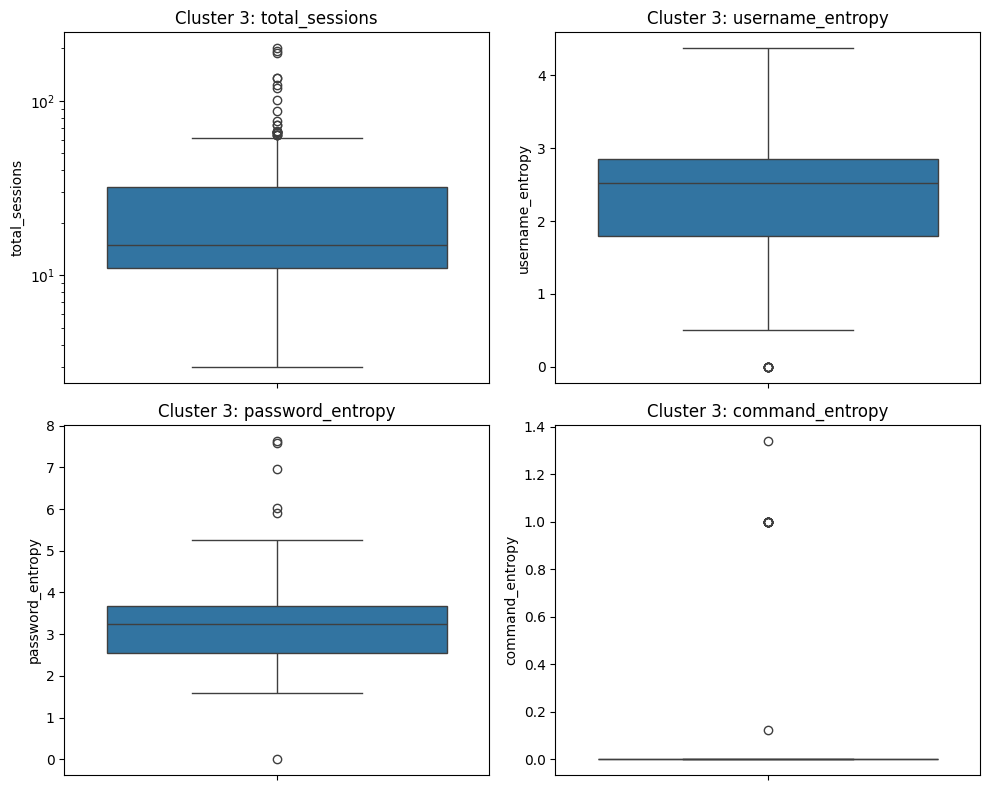

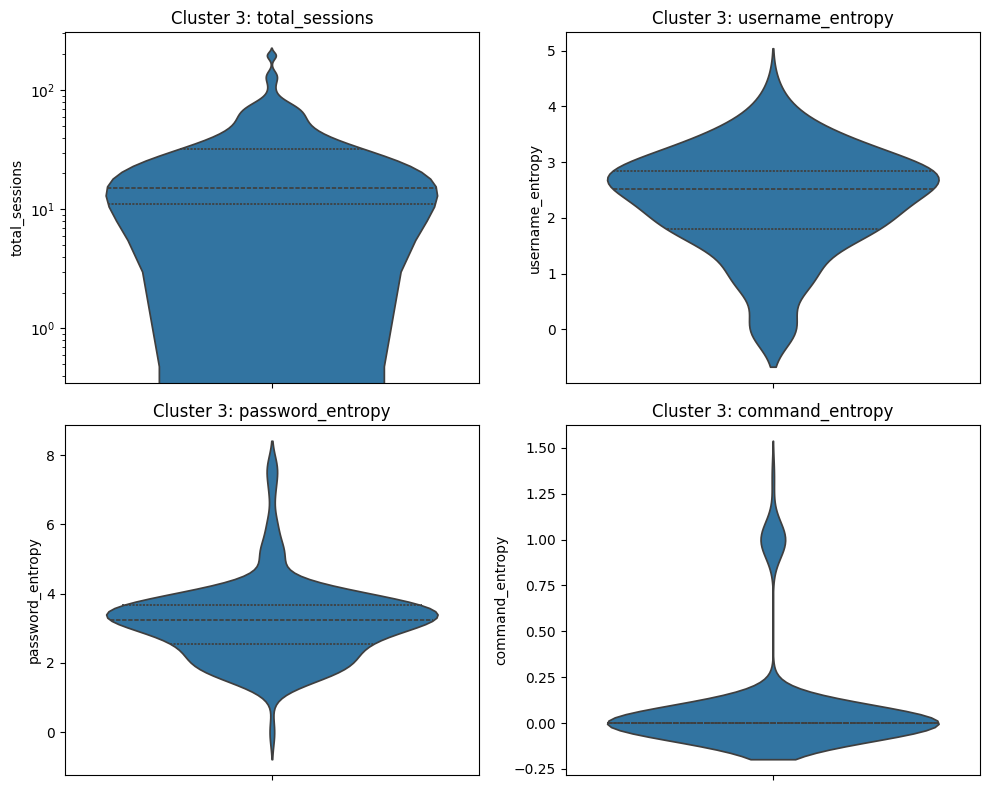

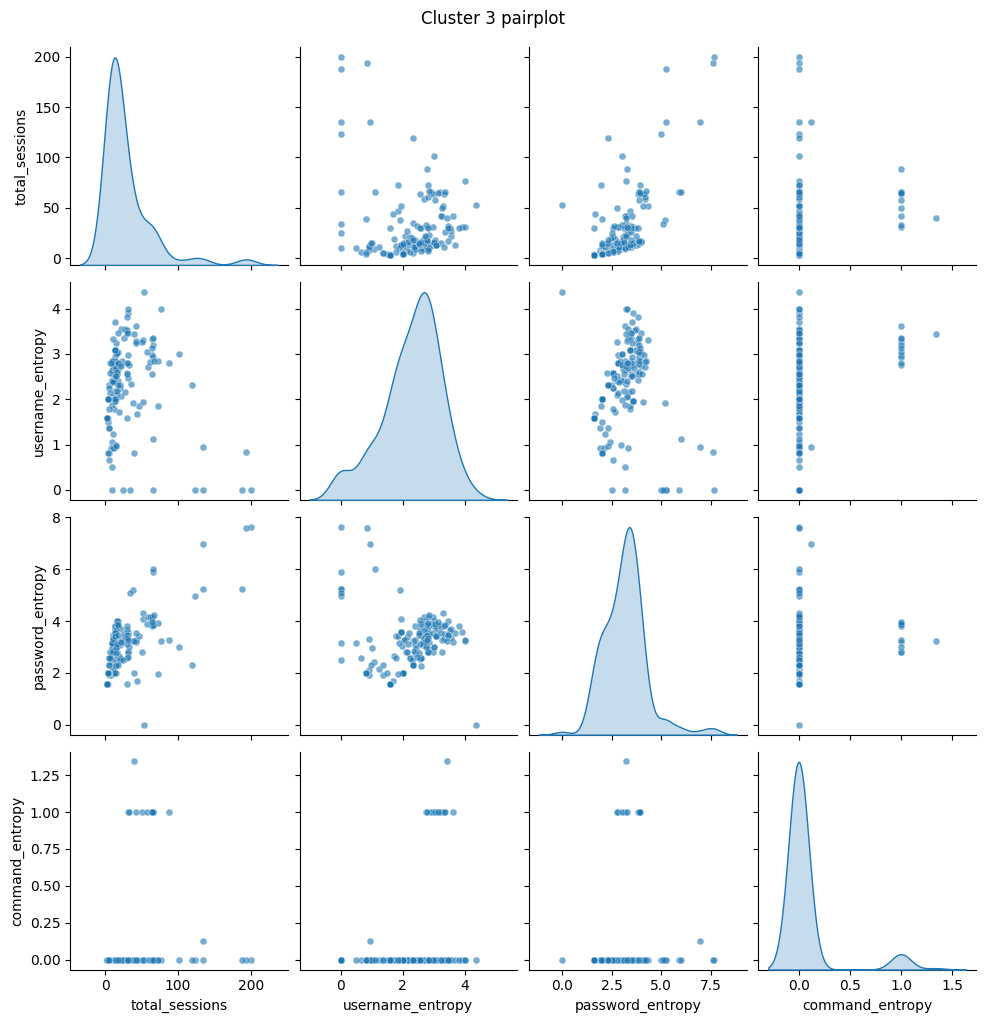

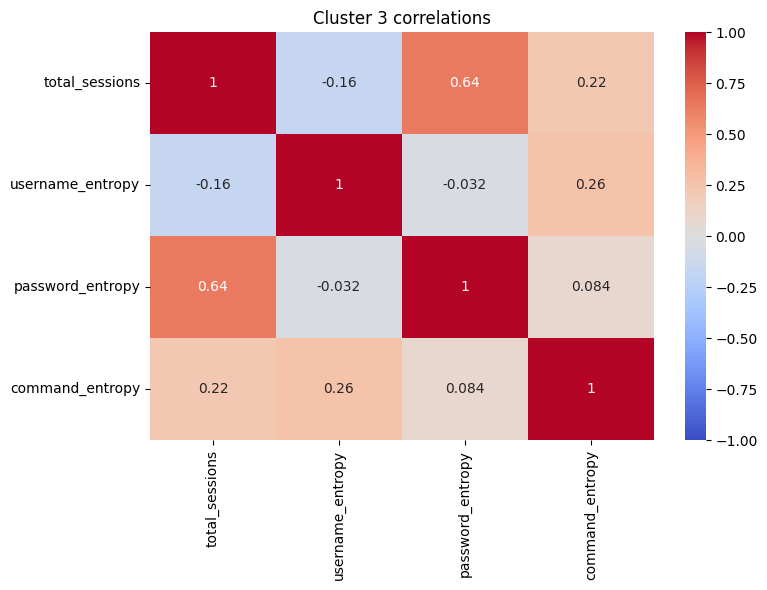

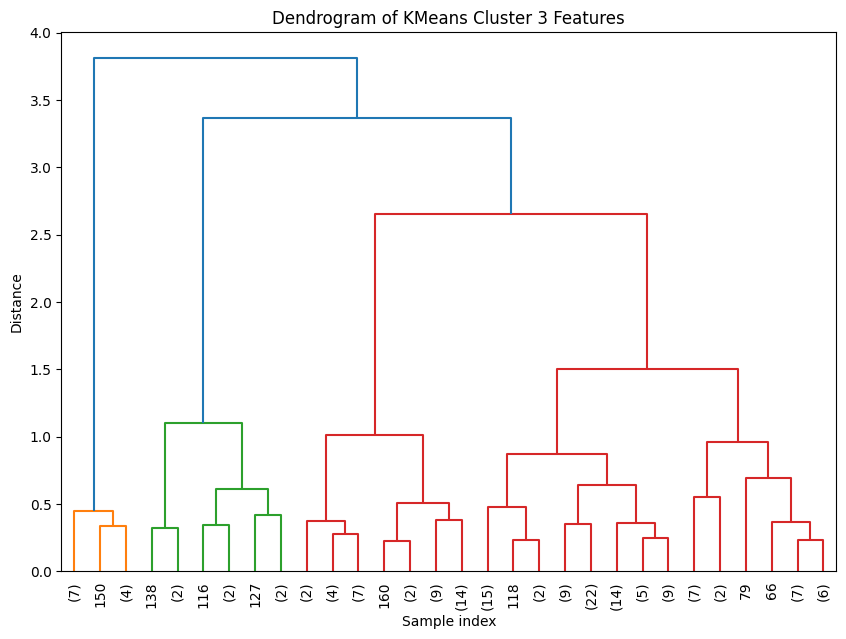

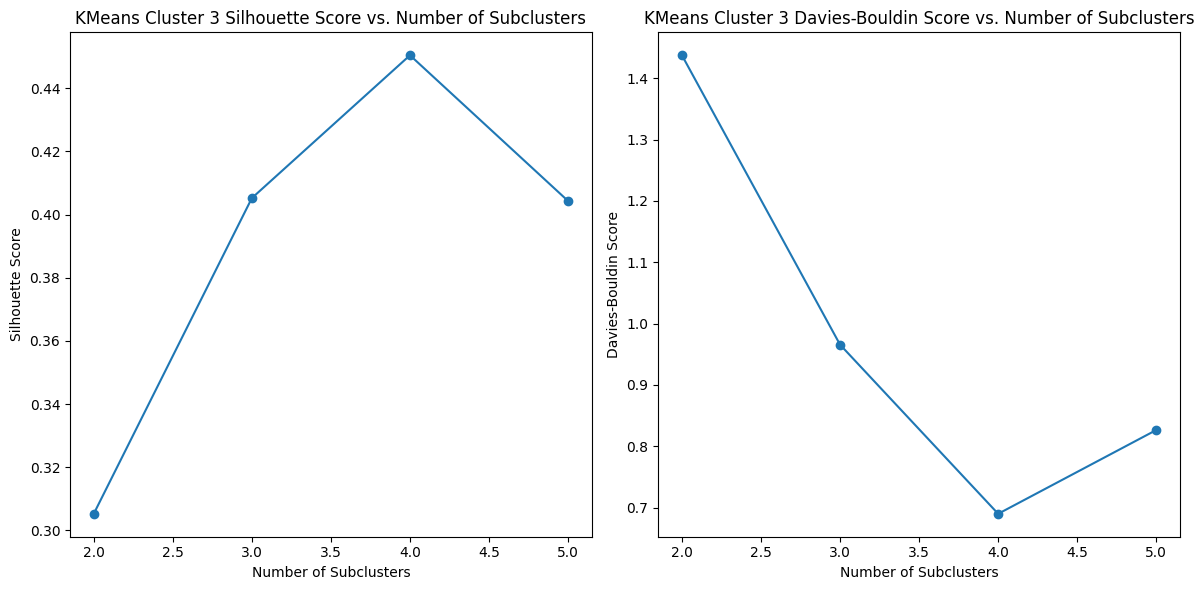

KMeans Cluster 3 Subcluster Labels:
              src_ip  total_sessions  username_entropy  password_entropy  \
35    101.108.53.147            52.0          3.296083          4.324797   
261  103.197.184.115            22.0          2.068794          3.260201   
262   103.197.184.12             9.0          1.061278          2.405639   
263  103.197.184.162            18.0          2.655639          3.077820   
264  103.197.184.167            16.0          2.093069          2.788450   

     command_entropy  kmeans_cluster  subcluster  
35               0.0               3           1  
261              0.0               3           2  
262              0.0               3           2  
263              0.0               3           1  
264              0.0               3           2  
KMeans Cluster 3 Subcluster Counts:
subcluster
1    89
2    72
Name: count, dtype: int64
KMeans Cluster 3 Centroids:
   total_sessions  username_entropy  password_entropy  command_entropy
0        0.13

/tmp/ipykernel_205858/2933451143.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kmeans_cluster_3['subcluster'] = kmeans_cluster_3_labels + 1


In [42]:
# analysis for cluster 3
boxplots_cluster(kmeans_cluster_3_clean, title_prefix="Cluster 3")
violins_cluster(kmeans_cluster_3_clean, title_prefix="Cluster 3")
pairplot_cluster(kmeans_cluster_3_clean, title="Cluster 3 pairplot")
corr_cluster3 = corr_heatmap_cluster(kmeans_cluster_3_clean, title="Cluster 3 correlations")
# make a dendrogram for cluster 3
# normalize cluster 3 data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
kmeans_cluster_3_normalized = scaler.fit_transform(kmeans_cluster_3_clean)
linked = linkage(kmeans_cluster_3_normalized, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(
    linked,
    truncate_mode='lastp',   # or 'level'
    p=30,                    # show only last 30 merged clusters
    show_leaf_counts=True,
    leaf_rotation=90,
)  
plt.title('Dendrogram of KMeans Cluster 3 Features')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.savefig('nov_14/cluster3/dendrogram_kmeans_cluster_3.png', dpi=300, bbox_inches='tight')
plt.show()

# find optimal number of subclusters for cluster 3 using silhouette and DBI
silhouette_scores = []
davies_bouldin_scores = []
k_range = range(2, 6)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(kmeans_cluster_3_normalized)
    silhouette_avg = silhouette_score(kmeans_cluster_3_normalized, labels)
    dbi = davies_bouldin_score(kmeans_cluster_3_normalized, labels)
    silhouette_scores.append(silhouette_avg)
    davies_bouldin_scores.append(dbi)
# Plotting the scores   
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('KMeans Cluster 3 Silhouette Score vs. Number of Subclusters')
plt.xlabel('Number of Subclusters')
plt.ylabel('Silhouette Score')
plt.subplot(1, 2, 2)
plt.plot(k_range, davies_bouldin_scores, marker='o')
plt.title('KMeans Cluster 3 Davies-Bouldin Score vs. Number of Subclusters')
plt.xlabel('Number of Subclusters')
plt.ylabel('Davies-Bouldin Score')
plt.tight_layout()
plt.savefig('nov_14/cluster3/kmeans_cluster3_subcluster_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()



# find centroids for cluster 3
kmeans_cluster_3_kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans_cluster_3_kmeans.fit(kmeans_cluster_3_normalized)
kmeans_cluster_3_labels = kmeans_cluster_3_kmeans.labels_
kmeans_cluster_3['subcluster'] = kmeans_cluster_3_labels + 1
print("KMeans Cluster 3 Subcluster Labels:")
print(kmeans_cluster_3.head())
print("KMeans Cluster 3 Subcluster Counts:")
print(kmeans_cluster_3['subcluster'].value_counts())
# centroids
centroids_cluster_3 = kmeans_cluster_3_kmeans.cluster_centers_
centroids_cluster_3_df = pd.DataFrame(centroids_cluster_3, columns=features)
print("KMeans Cluster 3 Centroids:")
print(centroids_cluster_3_df)             

#### cluster 4 analysis

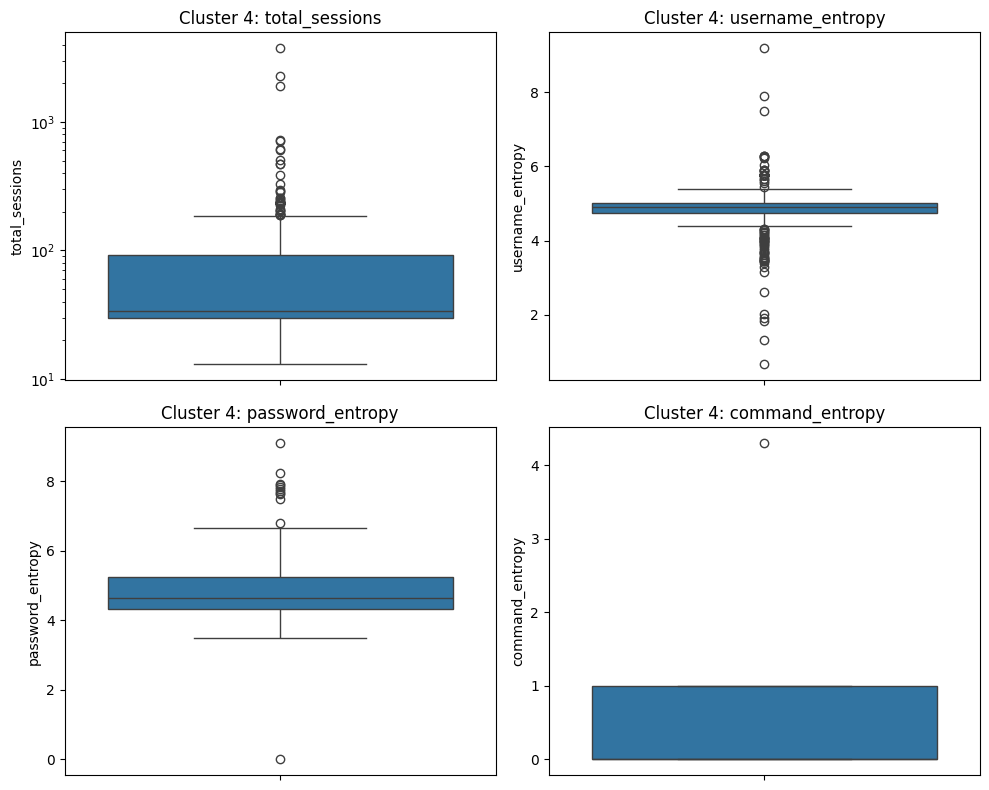

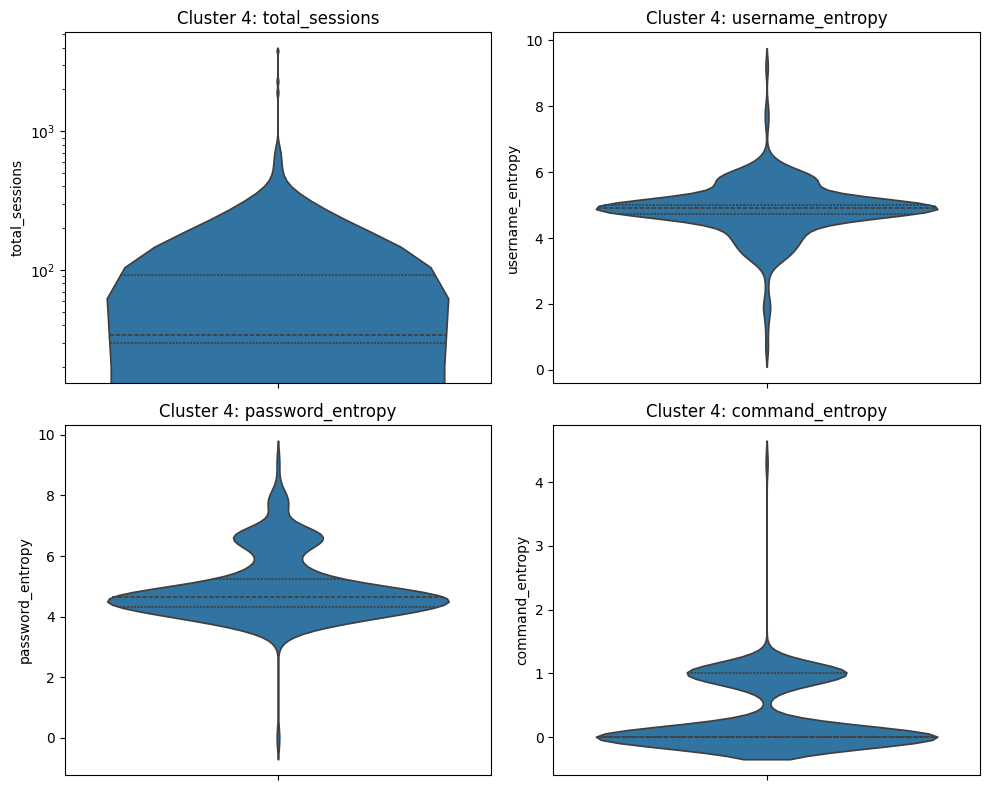

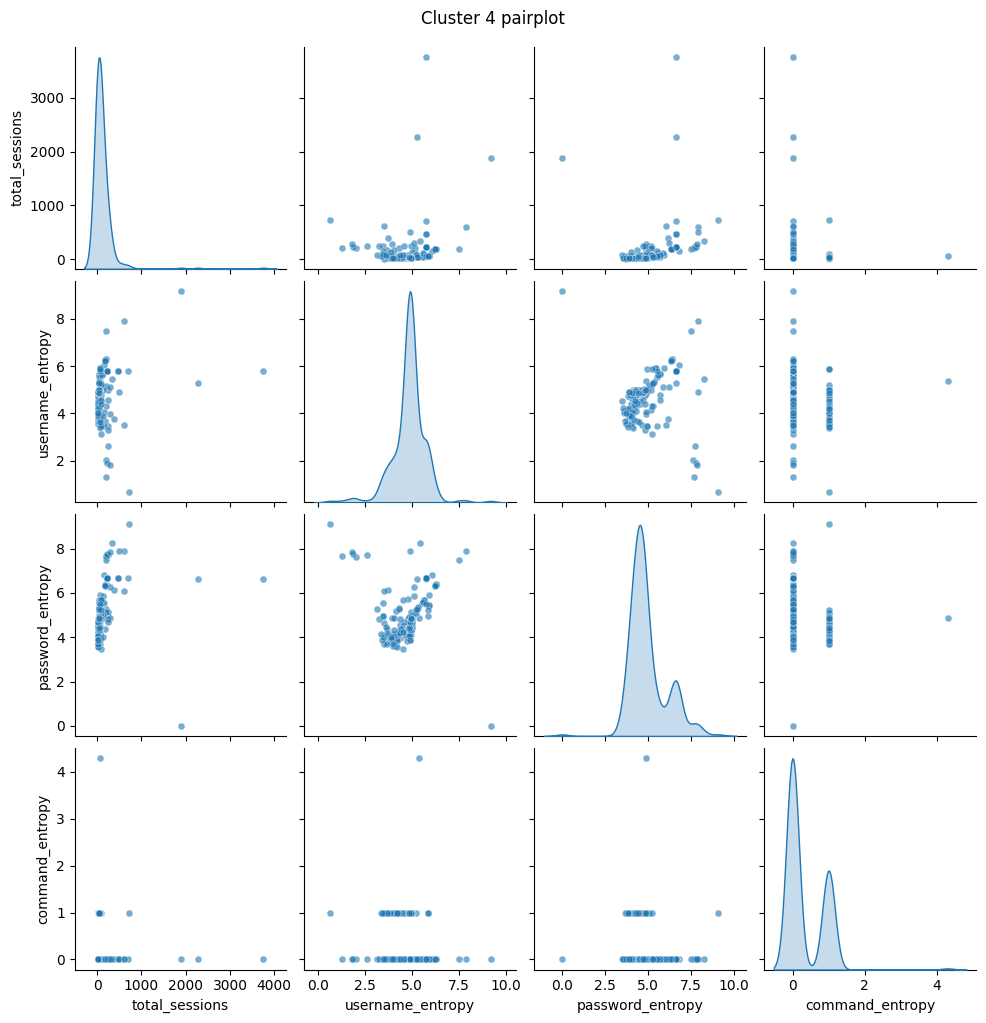

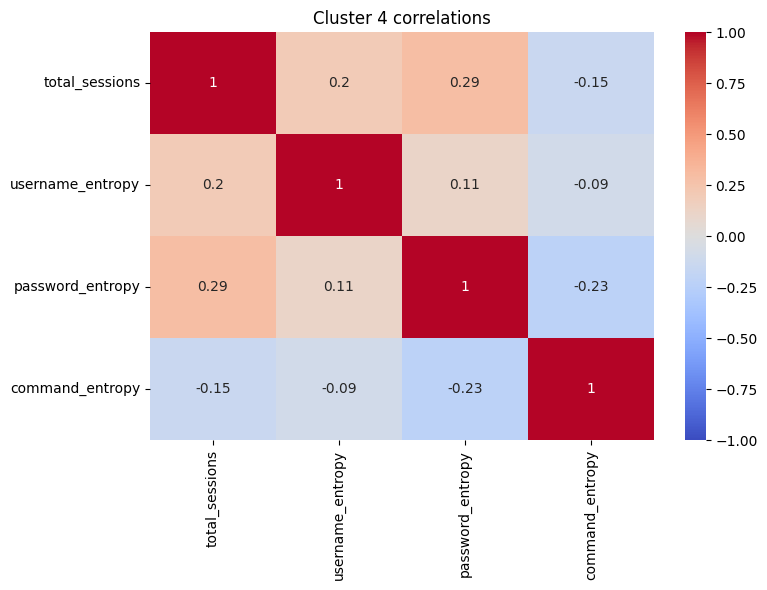

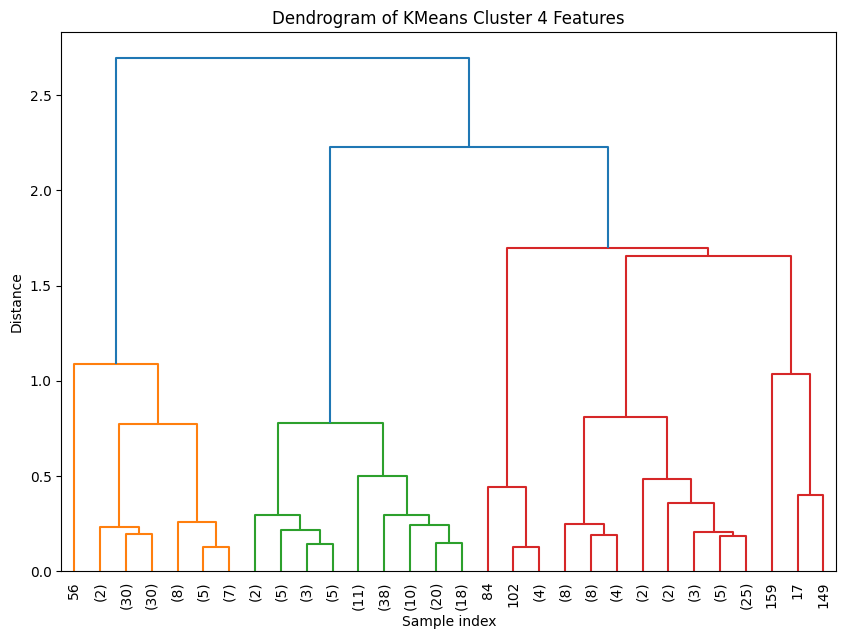

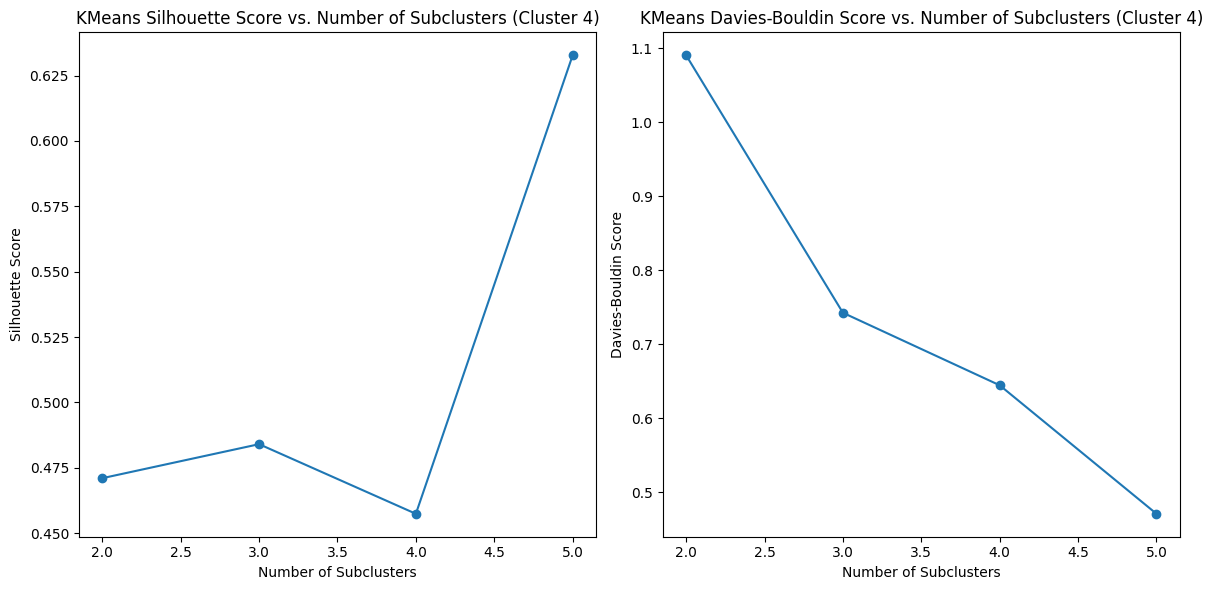

KMeans Cluster 4 Subcluster Labels:
             src_ip  total_sessions  username_entropy  password_entropy  \
78   101.126.89.144            29.0          4.142664          4.142664   
131    103.10.45.57            30.0          4.906891          4.681728   
177   103.151.20.98            30.0          4.906891          4.389898   
180  103.154.87.242            30.0          4.840224          4.519903   
217  103.176.78.193            30.0          4.840224          4.251841   

     command_entropy  kmeans_cluster  subcluster  
78               1.0               4           2  
131              0.0               4           2  
177              0.0               4           2  
180              0.0               4           2  
217              0.0               4           2  
KMeans Cluster 4 Subcluster Counts:
subcluster
2    202
1     59
Name: count, dtype: int64
KMeans Cluster 4 Centroids:
   total_sessions  username_entropy  password_entropy  command_entropy
0        0.087549

/tmp/ipykernel_205858/1513338177.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kmeans_cluster_4['subcluster'] = kmeans_cluster_4_labels + 1


In [43]:
# cluster 4 analysis
boxplots_cluster(kmeans_cluster_4_clean, title_prefix="Cluster 4")
violins_cluster(kmeans_cluster_4_clean, title_prefix="Cluster 4")
pairplot_cluster(kmeans_cluster_4_clean, title="Cluster 4 pairplot")
corr_cluster4 = corr_heatmap_cluster(kmeans_cluster_4_clean, title="Cluster 4 correlations")
# make a dendrogram for cluster 4
# normalize cluster 4 data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
kmeans_cluster_4_normalized = scaler.fit_transform(kmeans_cluster_4_clean) 
linked = linkage(kmeans_cluster_4_normalized, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(
    linked,
    truncate_mode='lastp',   # or 'level'
    p=30,                    # show only last 30 merged clusters
    show_leaf_counts=True,
    leaf_rotation=90,
)  
plt.title('Dendrogram of KMeans Cluster 4 Features')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.savefig('nov_14/cluster4/dendrogram_kmeans_cluster_4.png', dpi=300, bbox_inches='tight')
plt.show() 

# find optimal subclusters for cluster 4
silhouette_scores = []
davies_bouldin_scores = []
k_range = range(2, 6)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(kmeans_cluster_4_normalized)
    silhouette_avg = silhouette_score(kmeans_cluster_4_normalized, labels)
    dbi = davies_bouldin_score(kmeans_cluster_4_normalized, labels)
    silhouette_scores.append(silhouette_avg)
    davies_bouldin_scores.append(dbi)
# Plotting the scores
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('KMeans Silhouette Score vs. Number of Subclusters (Cluster 4)')
plt.xlabel('Number of Subclusters')
plt.ylabel('Silhouette Score')
plt.subplot(1, 2, 2)
plt.plot(k_range, davies_bouldin_scores, marker='o')
plt.title('KMeans Davies-Bouldin Score vs. Number of Subclusters (Cluster 4)')
plt.xlabel('Number of Subclusters')
plt.ylabel('Davies-Bouldin Score')
plt.tight_layout()
plt.savefig('nov_14/cluster4/kmeans_cluster4_subcluster_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()  


# find centroids for cluster 4
kmeans_cluster_4_kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans_cluster_4_kmeans.fit(kmeans_cluster_4_normalized)
kmeans_cluster_4_labels = kmeans_cluster_4_kmeans.labels_
kmeans_cluster_4['subcluster'] = kmeans_cluster_4_labels + 1
print("KMeans Cluster 4 Subcluster Labels:")
print(kmeans_cluster_4.head())
print("KMeans Cluster 4 Subcluster Counts:")
print(kmeans_cluster_4['subcluster'].value_counts())
# centroids
centroids_cluster_4 = kmeans_cluster_4_kmeans.cluster_centers_
centroids_cluster_4_df = pd.DataFrame(centroids_cluster_4, columns=features)
print("KMeans Cluster 4 Centroids:")
print(centroids_cluster_4_df)